In [192]:
import pandas as pd
import numpy as np
import ast, math
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as scp
from collections import Counter

pd.set_option('display.max_rows', None)     # tampilkan semua baris
pd.set_option('display.max_columns', None)  # tampilkan semua kolom
pd.set_option('display.width', None)        # biar nggak wrap otomatis
pd.set_option('display.max_colwidth', None) # biar kolom teks panjang tampil penuh

In [193]:
import warnings
warnings.filterwarnings('ignore')

In [194]:
# Load dataset
match_data = pd.read_csv('/Users/ramaharmono/TK Kasdad/klasifikasi/train.csv')
events_data = pd.read_csv('/Users/ramaharmono/TK Kasdad/klasifikasi/events_train.csv')
starting_xi = pd.read_csv('/Users/ramaharmono/TK Kasdad/klasifikasi/startingxi.csv')
positions_guide = pd.read_csv('/Users/ramaharmono/TK Kasdad/klasifikasi/position_guide.csv')
test_data = pd.read_csv('/Users/ramaharmono/TK Kasdad/klasifikasi/test.csv')

In [195]:
events_data['match_id'] = events_data['match_id'].astype(int)
match_data['match_id'] = match_data['match_id'].astype(int)

# pilih hanya kolom match_id + home_team.home_team_name lalu rename untuk kemudahan
match_home = match_data[['match_id', 'home_team.home_team_name','away_team.away_team_name']].rename(
    columns={'home_team.home_team_name': 'home_team_name',
             'away_team.away_team_name': 'away_team_name'}

)

# merge ke events (left join agar semua events tetap ada)
events_merged = events_data.merge(match_home, on='match_id', how='left')

# quick check
print(events_merged[['match_id','home_team_name','away_team_name']].tail(50))

        match_id home_team_name away_team_name
328625   3773547      Barcelona        Osasuna
328626   3773547      Barcelona        Osasuna
328627   3773547      Barcelona        Osasuna
328628   3773547      Barcelona        Osasuna
328629   3773547      Barcelona        Osasuna
328630   3773547      Barcelona        Osasuna
328631   3773547      Barcelona        Osasuna
328632   3773547      Barcelona        Osasuna
328633   3773547      Barcelona        Osasuna
328634   3773547      Barcelona        Osasuna
328635   3773547      Barcelona        Osasuna
328636   3773547      Barcelona        Osasuna
328637   3773547      Barcelona        Osasuna
328638   3773547      Barcelona        Osasuna
328639   3773547      Barcelona        Osasuna
328640   3773547      Barcelona        Osasuna
328641   3773547      Barcelona        Osasuna
328642   3773547      Barcelona        Osasuna
328643   3773547      Barcelona        Osasuna
328644   3773547      Barcelona        Osasuna
328645   3773

**1.) Exploratory Data Analysis (EDA)**

helper functions

In [196]:
def missing_values_info(df,arr):
    for col in df:
        missing = df[col].isna().sum()
        arr.append([col, missing, (missing/len(events_data))*100])

missing_info = []
#sortir informasi missing values
missing_values_info(events_merged, missing_info)
missing_df = pd.DataFrame(missing_info, columns=['Column', 'Missing Values', 'Percentage'])
missing_df = missing_df.sort_values(by='Missing Values', ascending=False)
print(missing_df)

                               Column  Missing Values  Percentage
98             goalkeeper.success_out          328675  100.000000
92                goalkeeper.lost_out          328674   99.999696
100           goalkeeper.lost_in_play          328674   99.999696
99               player_off.permanent          328674   99.999696
89                      shot.redirect          328674   99.999696
95         goalkeeper.success_in_play          328673   99.999391
97               shot.follows_dribble          328672   99.999087
90                 shot.saved_to_post          328669   99.998174
87   goalkeeper.shot_saved_off_target          328669   99.998174
86              shot.saved_off_target          328669   99.998174
91      goalkeeper.shot_saved_to_post          328668   99.997870
88             goalkeeper.punched_out          328666   99.997262
85                   dribble.no_touch          328666   99.997262
96                   block.save_block          328662   99.996045
94        

In [197]:
def drop_cols_by_names (df, col_names):
    return df.drop(columns=col_names)

membuat klasifikasi untuk kolom - kolom pada dataset events berdasarkan jenis event sepeti pass, shot, dribble, serta saved yg diambil dari goalkeeper.

In [198]:
goalkeeper_cols = ['goalkeeper.success_out','goalkeeper.lost_out','shot.redirect','goalkeeper.lost_in_play','goalkeeper.success_in_play','goalkeeper.shot_saved_off_target','goalkeeper.shot_saved_to_post',
                   'goalkeeper.punched_out','goalkeeper.body_part.name','goalkeeper.technique.name','goalkeeper.outcome.name','goalkeeper.end_location','goalkeeper.position.name','goalkeeper.type.name']
passing_cols = ['pass.miscommunication','pass.deflected','pass.no_touch','pass.cut_back','pass.goal_assist','pass.outswinging','pass.inswinging','pass.through_ball','pass.aerial_won','pass.technique.name',
                'pass.shot_assist','pass.cross','pass.switch','pass.type.name','pass.outcome.name','pass.recipient.name','pass.body_part.name','pass.height.name','pass.angle','pass.end_location']
shoting_cols = ['shot.follows_dribble','shot.saved_off_target','shot.saved_to_post','shot.open_goal','shot.deflected','shot.aerial_won','shot.aerial_won','shot.first_time','shot.technique.name','shot.type.name',
                'shot.end_location','shot.body_part.name','shot.outcome.name']
dribble_cols = ['dribble.outcome.name','dribble.nutmeg','dribble.overrun','dribble.no_touch']

melakukan pembuangan kolom yang memiliki persentase missing values yang besar serta tidak relevan untuk dilanjukan ke tahap preprocessing dan modeling.

In [199]:
high_col_percent_missing =['goalkeeper.success_out','goalkeeper.lost_out','goalkeeper.lost_in_play','shot.saved_off_target','shot.follows_dribble','shot.saved_off_target','goalkeeper.shot_saved_off_target','goalkeeper.punched_out','dribble.no_touch','pass.cut_back','pass.outswinging',
                           'substitution.replacement.name','substitution.outcome.name',
                           'goalkeeper.body_part.name','goalkeeper.technique.name','out','shot.body_part.name',
                           'pass.recipient.name','pass.body_part.name','pass.height.name','off_camera','shot.first_time','shot.redirect','shot.follows_dribble',
                           'dribble.nutmeg','dribble.overrun','dribble.no_touch','clearance.other','injury_stoppage.in_chain','goalkeeper.position.name',
                           'goalkeeper.type.name','timestamp','type.name','duel.type.name','pass.type.name','id','player.name','related_events',
                           'play_pattern.name','location','pass.angle','pass.end_location','shot.end_location','shot.technique.name','pass.technique.name',
                           'shot.type.name','shot.deflected','pass.shot_assist','pass.cross','pass.switch','pass.through_ball','pass.aerial_won','pass.miscommunication','pass.deflected','pass.no_touch']

copied_df = drop_cols_by_names(events_merged, high_col_percent_missing)

missing_values = []
missing_values_info(copied_df,missing_values)

index_output = list(range(0, len(missing_values)))
(pd.DataFrame(missing_values, columns=['Fitur', '# Missing','% Missing'], index=index_output).sort_values(by=['% Missing'], ascending=False, ignore_index=True))

,Fitur,# Missing,% Missing
0,player_off.permanent,328674,99.999696
1,goalkeeper.success_in_play,328673,99.999391
2,shot.saved_to_post,328669,99.998174
3,goalkeeper.shot_saved_to_post,328668,99.997870
4,block.save_block,328662,99.996045
5,foul_won.penalty,328661,99.995740
6,foul_committed.penalty,328655,99.993915
7,shot.open_goal,328651,99.992698
8,ball_recovery.offensive,328651,99.992698
9,pass.straight,328638,99.988743


Melakukan konversi tipe data pada beberapa kolom yang sesuai dengan tipe data yang diinginkan.

In [200]:
copied_df.dtypes

index                               int64
period                              int64
possession                          int64
duration                          float64
possession_team.name               object
team.name                          object
under_pressure                     object
carry.end_location                 object
dribble.outcome.name               object
duel.outcome.name                  object
50_50.outcome.name                 object
shot.outcome.name                  object
goalkeeper.end_location            object
pass.outcome.name                  object
ball_receipt.outcome.name          object
counterpress                       object
clearance.left_foot                object
clearance.body_part.name           object
clearance.right_foot               object
clearance.head                     object
foul_won.defensive                 object
interception.outcome.name          object
goalkeeper.outcome.name            object
ball_recovery.recovery_failure    

In [201]:
bool_cols = [
    'under_pressure', 'counterpress', 'pass.switch', 'pass.cross', 'pass.goal_assist',
    'pass.shot_assist', 'shot.first_time', 'shot.open_goal', 'shot.one_on_one',
    'clearance.left_foot', 'clearance.right_foot', 'clearance.head',
    'foul_committed.penalty', 'foul_won.penalty'
]

for col in bool_cols:
    if col in copied_df.columns:
        copied_df[col] = copied_df[col].apply(lambda x: 1 if x == True or x == 'TRUE' else 0)

copied_df.dtypes

index                               int64
period                              int64
possession                          int64
duration                          float64
possession_team.name               object
team.name                          object
under_pressure                      int64
carry.end_location                 object
dribble.outcome.name               object
duel.outcome.name                  object
50_50.outcome.name                 object
shot.outcome.name                  object
goalkeeper.end_location            object
pass.outcome.name                  object
ball_receipt.outcome.name          object
counterpress                        int64
clearance.left_foot                 int64
clearance.body_part.name           object
clearance.right_foot                int64
clearance.head                      int64
foul_won.defensive                 object
interception.outcome.name          object
goalkeeper.outcome.name            object
ball_recovery.recovery_failure    

Melakukan feature engineering berdasarkan domain knowledge sepak bola untuk menambah kolom - kolom baru yang dapat membantu dalam analisis dan pemodelan selanjutnya.

In [202]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['shot.outcome.name', 'pass.outcome.name', 'duel.outcome.name','dribble.outcome.name',
            'interception.outcome.name','block.save_block','goalkeeper.shot_saved_to_post','goalkeeper.outcome.name',
            'foul_won.penalty','foul_committed.penalty']
le = LabelEncoder()
for col in cat_cols:
    if col in copied_df.columns: 
        copied_df[col] = copied_df[col].astype(str).fillna('Unknown')
        copied_df[col] = le.fit_transform(copied_df[col])

copied_df.dtypes

index                               int64
period                              int64
possession                          int64
duration                          float64
possession_team.name               object
team.name                          object
under_pressure                      int64
carry.end_location                 object
dribble.outcome.name                int64
duel.outcome.name                   int64
50_50.outcome.name                 object
shot.outcome.name                   int64
goalkeeper.end_location            object
pass.outcome.name                   int64
ball_receipt.outcome.name          object
counterpress                        int64
clearance.left_foot                 int64
clearance.body_part.name           object
clearance.right_foot                int64
clearance.head                      int64
foul_won.defensive                 object
interception.outcome.name           int64
goalkeeper.outcome.name             int64
ball_recovery.recovery_failure    

In [203]:
copied_df.shape

(328675, 51)

In [204]:
copied_df.tail(100)

,index,period,possession,duration,possession_team.name,team.name,under_pressure,carry.end_location,dribble.outcome.name,duel.outcome.name,50_50.outcome.name,shot.outcome.name,goalkeeper.end_location,pass.outcome.name,ball_receipt.outcome.name,counterpress,clearance.left_foot,clearance.body_part.name,clearance.right_foot,clearance.head,foul_won.defensive,interception.outcome.name,goalkeeper.outcome.name,ball_recovery.recovery_failure,clearance.aerial_won,pass.goal_assist,pass.inswinging,ball_recovery.offensive,shot.aerial_won,shot.open_goal,shot.one_on_one,foul_committed.card.name,block.deflection,match_id,pass.straight,bad_behaviour.card.name,foul_committed.offensive,foul_committed.type.name,foul_committed.advantage,foul_won.advantage,block.offensive,miscontrol.aerial_won,shot.saved_to_post,goalkeeper.shot_saved_to_post,foul_committed.penalty,foul_won.penalty,goalkeeper.success_in_play,block.save_block,player_off.permanent,home_team_name,away_team_name
328575,3937,2,221,0.866364,Barcelona,Barcelona,0,"[14.6, 45.6]",2,5,NaN,8,NaN,5,NaN,0,0,NaN,0,0,NaN,5,16,NaN,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,NaN,1,NaN,Barcelona,Osasuna
328576,3938,2,221,1.311819,Barcelona,Barcelona,0,NaN,2,5,NaN,8,NaN,5,NaN,0,0,NaN,0,0,NaN,5,16,NaN,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,NaN,1,NaN,Barcelona,Osasuna
328577,3939,2,221,NaN,Barcelona,Barcelona,0,NaN,2,5,NaN,8,NaN,5,NaN,0,0,NaN,0,0,NaN,5,16,NaN,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,NaN,1,NaN,Barcelona,Osasuna
328578,3940,2,221,1.415417,Barcelona,Barcelona,0,"[34.6, 61.4]",2,5,NaN,8,NaN,5,NaN,0,0,NaN,0,0,NaN,5,16,NaN,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,NaN,1,NaN,Barcelona,Osasuna
328579,3941,2,221,2.032596,Barcelona,Barcelona,0,NaN,2,5,NaN,8,NaN,5,NaN,0,0,NaN,0,0,NaN,5,16,NaN,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,NaN,1,NaN,Barcelona,Osasuna
328580,3942,2,221,NaN,Barcelona,Barcelona,0,NaN,2,5,NaN,8,NaN,5,NaN,0,0,NaN,0,0,NaN,5,16,NaN,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,NaN,1,NaN,Barcelona,Osasuna
328581,3943,2,221,0.080000,Barcelona,Barcelona,0,"[50.4, 33.3]",2,5,NaN,8,NaN,5,NaN,0,0,NaN,0,0,NaN,5,16,NaN,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,NaN,1,NaN,Barcelona,Osasuna
328582,3944,2,221,1.152364,Barcelona,Barcelona,0,NaN,2,5,NaN,8,NaN,5,NaN,0,0,NaN,0,0,NaN,5,16,NaN,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,NaN,1,NaN,Barcelona,Osasuna
328583,3945,2,221,NaN,Barcelona,Barcelona,0,NaN,2,5,NaN,8,NaN,5,NaN,0,0,NaN,0,0,NaN,5,16,NaN,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,NaN,1,NaN,Barcelona,Osasuna
328584,3946,2,221,1.240049,Barcelona,Barcelona,0,"[48.3, 33.2]",2,5,NaN,8,NaN,5,NaN,0,0,NaN,0,0,NaN,5,16,NaN,NaN,0,NaN,NaN,NaN,0,0,NaN,NaN,3773547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,NaN,1,NaN,Barcelona,Osasuna


**Melakukan understanding data terhadap dataset events**

helper functions

In [205]:
for col in cat_cols:
    print(f"Value counts for {col}:")
    print(events_data[col].value_counts())
    print()

Value counts for shot.outcome.name:
shot.outcome.name
Off T               648
Saved               549
Blocked             511
Goal                274
Wayward              82
Post                 48
Saved to Post         6
Saved Off Target      6
Name: count, dtype: int64

Value counts for pass.outcome.name:
pass.outcome.name
Incomplete          12680
Out                  1229
Unknown               410
Pass Offside          343
Injury Clearance       79
Name: count, dtype: int64

Value counts for duel.outcome.name:
duel.outcome.name
Success In Play    1001
Won                 717
Lost In Play        579
Lost Out            443
Success Out         100
Name: count, dtype: int64

Value counts for dribble.outcome.name:
dribble.outcome.name
Complete      1727
Incomplete    1218
Name: count, dtype: int64

Value counts for interception.outcome.name:
interception.outcome.name
Won                795
Success In Play    509
Lost In Play       449
Lost Out           226
Success Out         10
Name:

In [206]:
for col in cat_cols:
    print(f"Value counts for {col}:")
    print(copied_df[col].value_counts())
    print()

Value counts for shot.outcome.name:
shot.outcome.name
8    326551
2       648
4       549
0       511
1       274
7        82
3        48
6         6
5         6
Name: count, dtype: int64

Value counts for pass.outcome.name:
pass.outcome.name
5    313934
0     12680
2      1229
4       410
3       343
1        79
Name: count, dtype: int64

Value counts for duel.outcome.name:
duel.outcome.name
5    325835
2      1001
4       717
0       579
1       443
3       100
Name: count, dtype: int64

Value counts for dribble.outcome.name:
dribble.outcome.name
2    325730
0      1727
1      1218
Name: count, dtype: int64

Value counts for interception.outcome.name:
interception.outcome.name
5    326686
4       795
2       509
0       449
1       226
3        10
Name: count, dtype: int64

Value counts for block.save_block:
block.save_block
1    328662
0        13
Name: count, dtype: int64

Value counts for goalkeeper.shot_saved_to_post:
goalkeeper.shot_saved_to_post
1    328668
0         7
Name: co

In [207]:
def is_barca(name: str) -> bool:
    return isinstance(name,str) and ('barcelona' in name.lower())

matches_barca = match_data[
    match_data['home_team.home_team_name'].apply(is_barca) |
    match_data['away_team.away_team_name'].apply(is_barca)
].copy()

**understanding data startingxi.csv dan positions_guide.csv**

In [208]:
# starting xi for team.name 'Barcelona'
starting_xi_barca = starting_xi[starting_xi['team.name'].apply(is_barca)].copy()
starting_xi_barca = starting_xi_barca.drop_duplicates(subset=['match_id', 'team.name']).reset_index(drop=True)
starting_xi_barca.head(5)

pos_cols = [c for c in starting_xi.columns if c.startswith('pos')]

rows = []
for _, r in starting_xi_barca.iterrows():
    for i in range(1, 26):
        pcol = f'pos{i}'
        player = r.get(pcol, None)
        if pd.notna(player) and str(player).strip() != '':
            rows.append({
                'match_id': r['match_id'],
                'team': r['team.name'],
                'position': i,
                'player': player,
            })

barca_starting_long = pd.DataFrame(rows)

In [209]:
positions_guide_copy = drop_cols_by_names(positions_guide,col_names='Position Name')
positions_guide_copy.rename(columns={'Position Abbreviation':'Position Name'}, inplace=True)
positions_guide_copy = positions_guide_copy.rename(columns={'Position Number': 'position', 'Position Name': 'position_name'})

positions_guide_copy.head(25)

barca_starting_long = barca_starting_long.merge(
    positions_guide_copy,
    on='position',
    how='left'
)

barca_starting_long.head(100)

,match_id,team,position,player,position_name
0,303680,Barcelona,1,Marc-André ter Stegen,GK
1,303680,Barcelona,2,Nélson Cabral Semedo,RB
2,303680,Barcelona,3,Gerard Piqué Bernabéu,RCB
3,303680,Barcelona,5,Clément Lenglet,LCB
4,303680,Barcelona,6,Jordi Alba Ramos,LB
5,303680,Barcelona,10,Sergio Busquets i Burgos,CDM
6,303680,Barcelona,13,Sergi Roberto Carnicer,RCM
7,303680,Barcelona,15,Ricard Puig Martí,LCM
8,303680,Barcelona,19,Arturo Erasmo Vidal Pardo,CAM
9,303680,Barcelona,22,Lionel Andrés Messi Cuccittini,RCF


In [210]:
# kategori formasi
ATTACKING = ['4-3-3', '4-2-4']
BALANCED  = ['4-4-2', '3-5-2']
DEFENSIVE = ['5-3-2', '4-5-1', '5-2-3', '5-4-1']

# kategori posisi
DEF_POS = set([2,3,4,5,6,7,8])
MID_POS = set([9,10,11,12,13,14,15,16,18,19,20])
FWD_POS = set([17,21,22,23,24,25])

# function bikin formasi
def bikin_formasi(starting_xi):
    formation_data = []
    
    for match_id, group in starting_xi.groupby('match_id'):
        teams_in_match = []
        
        for team_name, team_group in group.groupby('team.name'):
            # hitung posisi untuk setiap tim
            def_count = mid_count = fwd_count = 0
            
            # iterasi pos1-pos25
            for i in range(1, 26):
                pos_col = f'pos{i}'
                if pos_col in team_group.columns:
                    for _, row in team_group.iterrows():
                        if pd.notna(row[pos_col]) and str(row[pos_col]).strip():
                            if i in DEF_POS:
                                def_count += 1
                            elif i in MID_POS:
                                mid_count += 1
                            elif i in FWD_POS:
                                fwd_count += 1
            
            # kode formasi
            formation_code = f"{def_count}-{mid_count}-{fwd_count}"
            
            # kategori formasi
            def formation_category(code, d, m, f):
                if code in DEFENSIVE: return 'defensive'
                if code in ATTACKING: return 'offensive'  
                if code in BALANCED: return 'balanced'
                total = d + m + f
                if total == 0: return 'unknown'
                if d/total >= 0.45: return 'defensive'
                if f/total >= 0.25: return 'offensive'
                return 'balanced'
            
            formation_cat = formation_category(formation_code, def_count, mid_count, fwd_count)
            
            teams_in_match.append({
                'match_id': match_id,
                'team_name': team_name,
                'formation_code': formation_code,
                'formation_cat': formation_cat,
                'def_count': def_count,
                'mid_count': mid_count,
                'fwd_count': fwd_count
            })
        
        if len(teams_in_match) == 2:
            formation_data.extend(teams_in_match)
    
    return pd.DataFrame(formation_data)

In [211]:
# function untuk analisis formasi Barcelona vs lawan
def analisis_barca_vs_lawan(all_formations_df, df_temp):
    barca_matches = []
    
    for match_id in all_formations_df['match_id'].unique():
        match_teams = all_formations_df[all_formations_df['match_id'] == match_id]
        
        if len(match_teams) == 2:
            # cari tim Barcelona
            barca_team = match_teams[match_teams['team_name'].str.contains('Barcelona', case=False, na=False)]
            
            if not barca_team.empty:
                barca_data = barca_team.iloc[0]
                
                # cari tim lawan (yang bukan Barcelona)
                opponent_data = match_teams[~match_teams['team_name'].str.contains('Barcelona', case=False, na=False)].iloc[0]
                
                # ambil hasil pertandingan
                match_result = df_temp[df_temp['match_id'] == match_id]
                if not match_result.empty:
                    result_row = match_result.iloc[0]
                    
                    # cek Barcelona home/away
                    is_barca_home = str(result_row['home_team.home_team_name']).lower().find('barcelona') != -1
                    
                    if is_barca_home:
                        barca_goals = result_row['home_score']
                        opponent_goals = result_row['away_score']
                    else:
                        barca_goals = result_row['away_score'] 
                        opponent_goals = result_row['home_score']
                    
                    # hasil
                    if barca_goals > opponent_goals:
                        result = 'Win'
                    elif barca_goals == opponent_goals:
                        result = 'Draw'
                    else:
                        result = 'Lose'
                    
                    # ambil tahun
                    try:
                        year = pd.to_datetime(result_row['match_date']).year
                    except:
                        year = 'Unknown'
                    
                    barca_matches.append({
                        'match_id': match_id,
                        'formasi_barca': barca_data['formation_code'],
                        'formasi_lawan': opponent_data['formation_code'],
                        'tim_lawan': opponent_data['team_name'],
                        'gol_barca': barca_goals,
                        'gol_lawan': opponent_goals,
                        'hasil': result,
                        'tahun': year,
                        'is_home': is_barca_home,
                        'barca_def': barca_data['def_count'],
                        'barca_mid': barca_data['mid_count'],
                        'barca_fwd': barca_data['fwd_count'],
                        'opponent_def': opponent_data['def_count'],
                        'opponent_mid': opponent_data['mid_count'],
                        'opponent_fwd': opponent_data['fwd_count']
                    })
    
    return pd.DataFrame(barca_matches)

# buat data formasi untuk semua tim
all_formations_df = bikin_formasi(starting_xi)

aggregasi data events berdasarkan match id dan team id untuk mendapatkan kolom - kolom statistik tim pada setiap pertandingan yang nantinya akan digunakan untuk preprocessing dan modeling.

In [212]:
# buat colomn baru untuk ambil yang valuenya positif bagi barcelona
copied_df['dribble.successful'] = copied_df['dribble.outcome.name'].apply(lambda x: 1 if x == 1 else 0)
copied_df['shot.outcome.goal'] = copied_df['shot.outcome.name'].apply(lambda x: 1 if x == 1 else 0)
copied_df['interception.outcome.positive'] = copied_df['interception.outcome.name'].apply(lambda x: 1 if x == 2 or x == 4 else 0)
copied_df['goalkeeper.outcome.positive'] = copied_df['goalkeeper.outcome.name'].apply(lambda x: 1 if x in [15,12,9,1,0,11,14] else 0)
copied_df['total_clearance'] = copied_df[['clearance.left_foot', 'clearance.right_foot', 'clearance.head']].sum(axis=1)
copied_df['foul_won.penalty'] = copied_df['foul_won.penalty'].apply(lambda x: 1 if x == 1 else 0)
copied_df['foul_committed.penalty'] = copied_df['foul_committed.penalty'].apply(lambda x: 1 if x == 1 else 0)

In [213]:
team_candidates = ['possession_team.name']
team_col = next((c for c in team_candidates if c in copied_df.columns), None)

df = copied_df.copy()
df['_team_norm'] = df[team_col].astype(str).str.strip().str.lower()
df['_home_norm'] = df['home_team_name'].astype(str).str.strip().str.lower()
df['_away_norm'] = df['away_team_name'].astype(str).str.strip().str.lower()

home_events = df[df['_team_norm'] == df['_home_norm'].copy()]
away_events = df[df['_team_norm'] == df['_away_norm'].copy()]
print(f"Home events: {len(home_events)}, Away events: {len(away_events)}")

Home events: 171260, Away events: 157415


In [214]:
copied_df['event_positive'] = (
    copied_df['pass.goal_assist'] + 
    copied_df['shot.outcome.goal'] + 
    copied_df['dribble.successful'] + 
    copied_df['interception.outcome.positive'] + 
    copied_df['goalkeeper.outcome.positive'] + 
    copied_df['foul_won.penalty']
)

copied_df['event_negative'] = (
    copied_df['foul_committed.penalty'] +
    (1 - copied_df['dribble.successful']) + 
    (copied_df['pass.outcome.name'] != 0).astype(int)  # jika 0 = sukses
)

In [215]:
agg_cols = [
    'event_positive', 'event_negative',
    'dribble.successful', 'pass.goal_assist', 'shot.outcome.goal',
    'goalkeeper.outcome.positive', 'interception.outcome.positive',
    'foul_won.penalty', 'foul_committed.penalty', 'total_clearance'
]

agg_home = copied_df.groupby(['match_id', 'home_team_name'])[agg_cols].sum().reset_index()
agg_away = copied_df.groupby(['match_id', 'away_team_name'])[agg_cols].sum().reset_index()

agg_home = agg_home.add_prefix('home_')
agg_away = agg_away.add_prefix('away_')

# gabungkan berdasarkan match_id
agg_match = pd.merge(
    agg_home, agg_away, left_on='home_match_id', right_on='away_match_id', how='outer', suffixes=('', '_y')
)
agg_match = agg_match.rename(columns={'home_match_id': 'match_id'})

In [216]:
agg_match['pos_event_diff'] = agg_match['home_event_positive'] - agg_match['away_event_positive']
agg_match['neg_event_diff'] = agg_match['home_event_negative'] - agg_match['away_event_negative']

agg_match['attack_efficiency_home'] = agg_match['home_shot.outcome.goal'] / (agg_match['home_event_positive'] + 1e-5)
agg_match['attack_efficiency_away'] = agg_match['away_shot.outcome.goal'] / (agg_match['away_event_positive'] + 1e-5)

agg_match['defense_efficiency_home'] = agg_match['home_goalkeeper.outcome.positive'] / (agg_match['home_event_negative'] + 1e-5)
agg_match['defense_efficiency_away'] = agg_match['away_goalkeeper.outcome.positive'] / (agg_match['away_event_negative'] + 1e-5)
agg_match.head(10)

,match_id,home_home_team_name,home_event_positive,home_event_negative,home_dribble.successful,home_pass.goal_assist,home_shot.outcome.goal,home_goalkeeper.outcome.positive,home_interception.outcome.positive,home_foul_won.penalty,home_foul_committed.penalty,home_total_clearance,away_match_id,away_away_team_name,away_event_positive,away_event_negative,away_dribble.successful,away_pass.goal_assist,away_shot.outcome.goal,away_goalkeeper.outcome.positive,away_interception.outcome.positive,away_foul_won.penalty,away_foul_committed.penalty,away_total_clearance,pos_event_diff,neg_event_diff,attack_efficiency_home,attack_efficiency_away,defense_efficiency_home,defense_efficiency_away
0,9742,Barcelona,60,7302,18,3,3,10,26,0,0,29,9742,Levante UD,60,7302,18,3,3,10,26,0,0,29,0,0,0.050000,0.050000,0.001369,0.001369
1,9754,Real Sociedad,49,7220,16,5,6,7,15,0,0,27,9754,Barcelona,49,7220,16,5,6,7,15,0,0,27,0,0,0.122449,0.122449,0.000970,0.000970
2,9765,Real Betis,46,7575,5,5,5,8,23,0,0,13,9765,Barcelona,46,7575,5,5,5,8,23,0,0,13,0,0,0.108696,0.108696,0.001056,0.001056
3,9774,Barcelona,55,6834,15,2,3,10,25,0,0,48,9774,Deportivo Alavés,55,6834,15,2,3,10,25,0,0,48,0,0,0.054545,0.054545,0.001463,0.001463
4,9783,Espanyol,55,6320,24,2,2,5,22,0,0,48,9783,Barcelona,55,6320,24,2,2,5,22,0,0,48,0,0,0.036364,0.036364,0.000791,0.000791
5,9794,Barcelona,66,6854,15,0,0,13,38,0,0,21,9794,Getafe,66,6854,15,0,0,13,38,0,0,21,0,0,0.000000,0.000000,0.001897,0.001897
6,9799,Eibar,55,7111,11,1,2,7,34,0,0,33,9799,Barcelona,55,7111,11,1,2,7,34,0,0,33,0,0,0.036364,0.036364,0.000984,0.000984
7,9811,Barcelona,69,6912,22,5,7,14,21,0,0,25,9811,Girona,69,6912,22,5,7,14,21,0,0,25,0,0,0.101449,0.101449,0.002025,0.002025
8,9827,Las Palmas,41,6509,18,0,2,9,12,0,1,28,9827,Barcelona,41,6509,18,0,2,9,12,0,1,28,0,0,0.048780,0.048780,0.001383,0.001383
9,9837,Barcelona,63,7749,24,0,1,10,28,0,0,23,9837,Atlético Madrid,63,7749,24,0,1,10,28,0,0,23,0,0,0.015873,0.015873,0.001290,0.001290


In [217]:
# pastikan kolom identifikasi tim & match
ev = copied_df.copy()

team_col = next((c for c in ['possession_team.name', 'team.name', 'team', 'possession_team'] if c in ev.columns), None)
if team_col is None:
    raise ValueError("Kolom team tidak ditemukan di events_data.")

ev['_team_norm'] = ev[team_col].astype(str).str.strip().str.lower()
ev['_home_norm'] = ev['home_team_name'].astype(str).str.strip().str.lower()
ev['_away_norm'] = ev['away_team_name'].astype(str).str.strip().str.lower()
ev['is_home'] = ev['_team_norm'] == ev['_home_norm']
ev['is_away'] = ev['_team_norm'] == ev['_away_norm']
ev['is_goal'] = ev['shot.outcome.name'].astype(str).str.contains('goal', case=False, na=False).astype(int)

agg_team = ev.groupby(['match_id', team_col]).agg(
    duration_mean=('duration', 'mean'),
    under_pressure_sum=('under_pressure', 'sum'),
    counterpress_sum=('counterpress', 'sum'),
    successful_passes=('pass.outcome.name', lambda x: (x == 0).sum()),
    successful_dribbles=('dribble.outcome.name', lambda x: (x == 0).sum()),
    interceptions=('interception.outcome.positive', 'sum'),
    goalkeeper_positive=('goalkeeper.outcome.positive', 'sum'),
    total_clearance=('total_clearance', 'sum'),
    foul_committed=('foul_committed.penalty', 'sum'),
    foul_won=('foul_won.penalty', 'sum'),
    goals=('is_goal', 'sum')
).reset_index()

agg_team = agg_team.merge(
    ev[['match_id', team_col, 'is_home', 'is_away']].drop_duplicates(),
    on=['match_id', team_col],
    how='left'
)

# ✅ merge home vs away pakai match_id
agg_home = agg_team[agg_team['is_home']]
agg_away = agg_team[agg_team['is_away']]

aggregated_features = pd.merge(
    agg_home,
    agg_away,
    on='match_id',
    how='outer',
    suffixes=('_home', '_away')
)

# ⚠️ JANGAN FLATTEN DULU — biarkan match_id tetap ada
# aggregated_features.columns = ['_'.join(col).strip('_') for col in aggregated_features.columns.values]  <-- hapus / komentarin

# lanjut bagian barca / non-barca
ev = events_data.copy()

# tanda goal: cek kolom teks dulu
if 'shot.outcome.name' in ev.columns:
    ev['shot_goal_flag'] = ev['shot.outcome.name'].astype(str).str.contains('goal', case=False, na=False).astype(int)
elif 'shot.outcome.goal' in ev.columns:
    ev['shot_goal_flag'] = ev['shot.outcome.goal'].fillna(0).astype(int)
else:
    ev['shot_goal_flag'] = 0

team_candidates = ['possession_team.name', 'team.name', 'team', 'possession_team']
team_col = next((c for c in team_candidates if c in ev.columns), None)

if team_col is None:
    print("Warning: team column not found in events_data — cannot compute Barcelona goals per match.")
    aggregated_features['shot.outcome.goal.barca'] = 0
    aggregated_features['shot.outcome.goal.nonbarca'] = 0
else:
    ev['is_barca'] = ev[team_col].astype(str).str.contains('barcelona', case=False, na=False)
    ev['is_nonbarca'] = ~ev['is_barca']

    barca_goals_per_match = (
        ev.loc[ev['is_barca'] & (ev['shot_goal_flag'] == 1)]
        .groupby('match_id')['shot_goal_flag']
        .sum()
        .rename('shot.outcome.goal.barca')
        .reset_index()
    )

    nonbarca_goals_per_match = (
        ev.loc[ev['is_nonbarca'] & (ev['shot_goal_flag'] == 1)]
        .groupby('match_id')['shot_goal_flag']
        .sum()
        .rename('shot.outcome.goal.nonbarca')
        .reset_index()
    )

    aggregated_features = (
        aggregated_features
        .merge(barca_goals_per_match, on='match_id', how='left')
        .merge(nonbarca_goals_per_match, on='match_id', how='left')
        .fillna({'shot.outcome.goal.barca': 0, 'shot.outcome.goal.nonbarca': 0})
    )

aggregated_features.head(10)

,match_id,possession_team.name_home,duration_mean_home,under_pressure_sum_home,counterpress_sum_home,successful_passes_home,successful_dribbles_home,interceptions_home,goalkeeper_positive_home,total_clearance_home,foul_committed_home,foul_won_home,goals_home,is_home_home,is_away_home,possession_team.name_away,duration_mean_away,under_pressure_sum_away,counterpress_sum_away,successful_passes_away,successful_dribbles_away,interceptions_away,goalkeeper_positive_away,total_clearance_away,foul_committed_away,foul_won_away,goals_away,is_home_away,is_away_away,shot.outcome.goal.barca,shot.outcome.goal.nonbarca
0,9742,Barcelona,1.181638,434,54,64,15,18,4,10,0,0,0,True,False,Levante UD,1.136273,354,51,54,6,8,6,19,0,0,0,False,True,3.0,0.0
1,9754,Real Sociedad,1.263976,468,53,84,10,9,4,17,0,0,0,True,False,Barcelona,1.275084,459,52,56,9,6,3,10,0,0,0,False,True,4.0,2.0
2,9765,Real Betis,1.217708,331,35,82,3,10,3,8,0,0,0,True,False,Barcelona,1.279247,488,67,74,20,13,5,5,0,0,0,False,True,5.0,0.0
3,9774,Barcelona,1.273502,422,74,95,16,20,6,31,0,0,0,True,False,Deportivo Alavés,1.344273,186,45,78,11,5,4,17,0,0,0,False,True,2.0,1.0
4,9783,Espanyol,0.973971,214,54,79,8,5,2,13,0,0,0,True,False,Barcelona,1.185643,388,68,103,11,17,3,35,0,0,0,False,True,1.0,1.0
5,9794,Barcelona,1.302541,384,74,109,12,27,5,20,0,0,0,True,False,Getafe,1.277433,129,25,76,3,11,8,1,0,0,0,False,True,0.0,0.0
6,9799,Eibar,1.234258,333,52,91,7,20,3,28,0,0,0,True,False,Barcelona,1.326094,332,50,97,9,14,4,5,0,0,0,False,True,2.0,0.0
7,9811,Barcelona,1.250031,343,50,75,20,13,9,14,0,0,0,True,False,Girona,1.256513,279,58,71,2,8,5,11,0,0,0,False,True,7.0,0.0
8,9827,Las Palmas,1.302636,249,42,57,11,8,6,12,1,0,0,True,False,Barcelona,1.223307,408,47,85,16,4,3,16,0,0,0,False,True,1.0,1.0
9,9837,Barcelona,1.058130,417,85,89,25,16,8,12,0,0,0,True,False,Atlético Madrid,1.150925,226,71,86,8,12,2,11,0,0,0,False,True,1.0,0.0


In [267]:
df_diff = aggregated_features.copy()

diff_features = [
    'duration_mean',
    'under_pressure_sum',
    'counterpress_sum',
    'successful_passes',
    'successful_dribbles',
    'interceptions',
    'goalkeeper_positive',
    'total_clearance',
    'foul_committed',
    'foul_won',
    'goals'
]

for f in diff_features:
    home_col = f"{f}_home"
    away_col = f"{f}_away"
    if home_col in df_diff.columns and away_col in df_diff.columns:
        df_diff[f"{f}_diff"] = df_diff[home_col].fillna(0) - df_diff[away_col].fillna(0)

df_diff["pass_efficiency_home"] = df_diff["successful_passes_home"] / (df_diff["successful_passes_home"] + df_diff["successful_passes_away"] + 1e-5)
df_diff["dribble_efficiency_home"] = df_diff["successful_dribbles_home"] / (df_diff["successful_dribbles_home"] + df_diff["successful_dribbles_away"] + 1e-5)
df_diff["defense_efficiency_home"] = df_diff["goalkeeper_positive_home"] / (df_diff["goalkeeper_positive_home"] + df_diff["goalkeeper_positive_away"] + 1e-5)

if "shot.outcome.goal.barca" in df_diff.columns and "shot.outcome.goal.nonbarca" in df_diff.columns:
    df_diff["barca_goal_diff"] = df_diff["shot.outcome.goal.barca"] - df_diff["shot.outcome.goal.nonbarca"]

print("✅ Difference & Efficiency features created!")
new_cols = [c for c in df_diff.columns if c.endswith("_diff") or c.endswith("_efficiency_home")]
print("New columns added:", new_cols[:15], "...")


aggregated_features = pd.merge(
    df_diff,
    aggregated_features[['match_id']],
    on='match_id',
    how='left'
)

aggregated_features.head(10)

✅ Difference & Efficiency features created!
New columns added: ['duration_mean_diff', 'under_pressure_sum_diff', 'counterpress_sum_diff', 'successful_passes_diff', 'successful_dribbles_diff', 'interceptions_diff', 'goalkeeper_positive_diff', 'total_clearance_diff', 'foul_committed_diff', 'foul_won_diff', 'goals_diff', 'pass_efficiency_home', 'dribble_efficiency_home', 'defense_efficiency_home', 'barca_goal_diff'] ...


,match_id,possession_team.name_home,duration_mean_home,under_pressure_sum_home,counterpress_sum_home,successful_passes_home,successful_dribbles_home,interceptions_home,goalkeeper_positive_home,total_clearance_home,foul_committed_home,foul_won_home,goals_home,is_home_home,is_away_home,possession_team.name_away,duration_mean_away,under_pressure_sum_away,counterpress_sum_away,successful_passes_away,successful_dribbles_away,interceptions_away,goalkeeper_positive_away,total_clearance_away,foul_committed_away,foul_won_away,goals_away,is_home_away,is_away_away,shot.outcome.goal.barca,shot.outcome.goal.nonbarca,duration_mean_diff,under_pressure_sum_diff,counterpress_sum_diff,successful_passes_diff,successful_dribbles_diff,interceptions_diff,goalkeeper_positive_diff,total_clearance_diff,foul_committed_diff,foul_won_diff,goals_diff,pass_efficiency_home,dribble_efficiency_home,defense_efficiency_home,barca_goal_diff
0,9742,Barcelona,1.181638,434,54,64,15,18,4,10,0,0,0,True,False,Levante UD,1.136273,354,51,54,6,8,6,19,0,0,0,False,True,3.0,0.0,0.045365,80,3,10,9,10,-2,-9,0,0,0,0.542373,0.714285,0.400000,3.0
1,9754,Real Sociedad,1.263976,468,53,84,10,9,4,17,0,0,0,True,False,Barcelona,1.275084,459,52,56,9,6,3,10,0,0,0,False,True,4.0,2.0,-0.011109,9,1,28,1,3,1,7,0,0,0,0.600000,0.526316,0.571428,2.0
2,9765,Real Betis,1.217708,331,35,82,3,10,3,8,0,0,0,True,False,Barcelona,1.279247,488,67,74,20,13,5,5,0,0,0,False,True,5.0,0.0,-0.061539,-157,-32,8,-17,-3,-2,3,0,0,0,0.525641,0.130435,0.375000,5.0
3,9774,Barcelona,1.273502,422,74,95,16,20,6,31,0,0,0,True,False,Deportivo Alavés,1.344273,186,45,78,11,5,4,17,0,0,0,False,True,2.0,1.0,-0.070771,236,29,17,5,15,2,14,0,0,0,0.549133,0.592592,0.599999,1.0
4,9783,Espanyol,0.973971,214,54,79,8,5,2,13,0,0,0,True,False,Barcelona,1.185643,388,68,103,11,17,3,35,0,0,0,False,True,1.0,1.0,-0.211672,-174,-14,-24,-3,-12,-1,-22,0,0,0,0.434066,0.421052,0.399999,0.0
5,9794,Barcelona,1.302541,384,74,109,12,27,5,20,0,0,0,True,False,Getafe,1.277433,129,25,76,3,11,8,1,0,0,0,False,True,0.0,0.0,0.025108,255,49,33,9,16,-3,19,0,0,0,0.589189,0.799999,0.384615,0.0
6,9799,Eibar,1.234258,333,52,91,7,20,3,28,0,0,0,True,False,Barcelona,1.326094,332,50,97,9,14,4,5,0,0,0,False,True,2.0,0.0,-0.091836,1,2,-6,-2,6,-1,23,0,0,0,0.484043,0.437500,0.428571,2.0
7,9811,Barcelona,1.250031,343,50,75,20,13,9,14,0,0,0,True,False,Girona,1.256513,279,58,71,2,8,5,11,0,0,0,False,True,7.0,0.0,-0.006482,64,-8,4,18,5,4,3,0,0,0,0.513699,0.909090,0.642857,7.0
8,9827,Las Palmas,1.302636,249,42,57,11,8,6,12,1,0,0,True,False,Barcelona,1.223307,408,47,85,16,4,3,16,0,0,0,False,True,1.0,1.0,0.079329,-159,-5,-28,-5,4,3,-4,1,0,0,0.401408,0.407407,0.666666,0.0
9,9837,Barcelona,1.058130,417,85,89,25,16,8,12,0,0,0,True,False,Atlético Madrid,1.150925,226,71,86,8,12,2,11,0,0,0,False,True,1.0,0.0,-0.092795,191,14,3,17,4,6,1,0,0,0,0.508571,0.757576,0.799999,1.0


In [268]:
# tambahkan possession features yang benar
temp_match = match_data[['match_id', 'home_team.home_team_name', 'away_team.away_team_name', 'Poss']].copy()
temp_match['barca_is_home'] = temp_match['home_team.home_team_name'].astype(str).str.contains('barcelona', case=False, na=False)
temp_match['barca_is_away'] = temp_match['away_team.away_team_name'].astype(str).str.contains('barcelona', case=False, na=False)

temp_match['barca_possession'] = np.where(temp_match['barca_is_home'], 100 - temp_match['Poss'], temp_match['Poss'])
temp_match['opponent_possession'] = 100 - temp_match['barca_possession']
temp_match['opponent_team'] = np.where(temp_match['barca_is_home'], temp_match['away_team.away_team_name'], temp_match['home_team.home_team_name'])

possession_features = temp_match[['match_id', 'barca_possession', 'opponent_possession', 'barca_is_home', 'barca_is_away', 'opponent_team']]

temp_df_merged = match_data.merge(aggregated_features, on='match_id', how='left')

barca_formation_df = analisis_barca_vs_lawan(all_formations_df, temp_df_merged)

In [269]:
temp_df_merged = temp_df_merged.merge(possession_features, on='match_id', how='left')

if not barca_formation_df.empty:
    formation_summary = barca_formation_df[['match_id', 'formasi_barca', 'formasi_lawan']].copy()
    df_merged = temp_df_merged.merge(formation_summary, on='match_id', how='left')
else:
    df_merged = temp_df_merged

test_merged = test_data.merge(aggregated_features, on='match_id', how='left')

helper function untuk ambil koordinat

In [270]:
def parse_xy(v):
    if pd.isna(v): return (np.nan, np.nan)
    if isinstance(v, str):
        try:
            arr = ast.literal_eval(v)
            if isinstance(arr, list) and len(arr) >= 2:
                return float(arr[0]), float(arr[1])
        except: return (np.nan, np.nan)
    return (np.nan, np.nan)

In [271]:
# parse koordinat dari location dan end_location
events_data['x'], events_data['y'] = zip(*events_data['location'].map(parse_xy))
if 'pass.end_location' in events_data.columns:
    events_data['end_x'], events_data['end_y'] = zip(*events_data['pass.end_location'].map(parse_xy))
elif 'end_location' in events_data.columns:
    events_data['end_x'], events_data['end_y'] = zip(*events_data['end_location'].map(parse_xy))
else:
    events_data['end_x'], events_data['end_y'] = np.nan, np.nan

# identifikasi event penting
events_data['type.name'] = events_data['type.name'].astype(str)
events_data['is_pass'] = events_data['type.name'].str.contains('Pass', case=False, na=False).astype(int)
events_data['is_shot'] = events_data['type.name'].str.contains('Shot', case=False, na=False).astype(int)
events_data['is_dribble'] = events_data['type.name'].str.contains('Dribble', case=False, na=False).astype(int)
events_data['is_duel'] = events_data['type.name'].str.contains('Duel', case=False, na=False).astype(int)

# panjang passes
def calc_len(row):
    if row['is_pass'] == 0 or pd.isna(row['x']) or pd.isna(row['end_x']):
        return np.nan
    return math.hypot(row['end_x'] - row['x'], row['end_y'] - row['y'])

events_data['pass_len'] = events_data.apply(calc_len, axis=1)

# agregasi per tim dan pertandingan 
agg = events_data.groupby(['match_id','team.name']).agg({
    'is_pass':'sum',
    'is_shot':'sum',
    'is_dribble':'sum',
    'is_duel':'sum',
    'pass_len':['mean'],
    'x':'mean'
}).reset_index()
agg.columns = ['match_id','team_name','num_pass','num_shot','num_dribble','num_duel','avg_pass_len','avg_x']

In [272]:
possession_data = df_merged[['match_id', 'barca_possession', 'opponent_possession', 
                            'home_team.home_team_name', 'away_team.away_team_name', 
                            'barca_is_home', 'barca_is_away']].copy()

In [273]:
barca_poss_list = []
for _, row in possession_data.iterrows():
    if row['barca_is_home']:
        barca_poss_list.append({
            'match_id': row['match_id'],
            'team_name': row['home_team.home_team_name'],
            'possession': row['barca_possession']
        })
        barca_poss_list.append({
            'match_id': row['match_id'],
            'team_name': row['away_team.away_team_name'],
            'possession': row['opponent_possession']
        })
    elif row['barca_is_away']:
        barca_poss_list.append({
            'match_id': row['match_id'],
            'team_name': row['away_team.away_team_name'],
            'possession': row['barca_possession']
        })
        barca_poss_list.append({
            'match_id': row['match_id'],
            'team_name': row['home_team.home_team_name'],
            'possession': row['opponent_possession']
        })

poss_all = pd.DataFrame(barca_poss_list)
agg = agg.merge(poss_all, on=['match_id','team_name'], how='left')

hitung z-score untuk normalisasi relatif antar tim 

In [274]:
for col in ['num_pass','num_shot','num_dribble','num_duel','avg_pass_len']:
    z = (agg[col] - agg[col].mean()) / (agg[col].std() + 1e-6)
    agg[f'{col}_z'] = z

In [275]:
print("=" * 60)
print("HASIL MERGE MATCH_DATA + AGGREGATED_FEATURES + PLAYSTYLE FEATURES")
print("=" * 60)
print(f"Match data shape: {match_data.shape}")
print(f"Aggregated features shape: {aggregated_features.shape}")
print(f"Playstyle aggregation shape: {agg.shape}")
print(f"Merged data shape: {df_merged.shape}")
print(f"Formation columns available: {[col for col in ['formasi_barca', 'formasi_lawan'] if col in df_merged.columns]}")

df_merged.head(100)

HASIL MERGE MATCH_DATA + AGGREGATED_FEATURES + PLAYSTYLE FEATURES
Match data shape: (85, 20)
Aggregated features shape: (85, 46)
Playstyle aggregation shape: (170, 14)
Merged data shape: (85, 72)
Formation columns available: ['formasi_barca', 'formasi_lawan']


,match_id,match_date,kick_off,home_score,away_score,match_week,home_team.home_team_name,away_team.away_team_name,stadium.name,referee.name,home_team.managers_name,home_team.managers_country,home_team.managers_dob,away_team.managers_name,away_team.managers_country,away_team.managers_dob,Poss,Result,season,year,possession_team.name_home,duration_mean_home,under_pressure_sum_home,counterpress_sum_home,successful_passes_home,successful_dribbles_home,interceptions_home,goalkeeper_positive_home,total_clearance_home,foul_committed_home,foul_won_home,goals_home,is_home_home,is_away_home,possession_team.name_away,duration_mean_away,under_pressure_sum_away,counterpress_sum_away,successful_passes_away,successful_dribbles_away,interceptions_away,goalkeeper_positive_away,total_clearance_away,foul_committed_away,foul_won_away,goals_away,is_home_away,is_away_away,shot.outcome.goal.barca,shot.outcome.goal.nonbarca,duration_mean_diff,under_pressure_sum_diff,counterpress_sum_diff,successful_passes_diff,successful_dribbles_diff,interceptions_diff,goalkeeper_positive_diff,total_clearance_diff,foul_committed_diff,foul_won_diff,goals_diff,pass_efficiency_home,dribble_efficiency_home,defense_efficiency_home,barca_goal_diff,barca_possession,opponent_possession,barca_is_home,barca_is_away,opponent_team,formasi_barca,formasi_lawan
0,9742,2018-01-07,16:15:00.000,3,0,18,Barcelona,Levante UD,Spotify Camp Nou,NaN,Ernesto Valverde Tejedor,Spain,1964-02-09,Juan Ramón López Muñiz,Spain,1968-11-02,29.0,Win,2018,2018,Barcelona,1.181638,434,54,64,15,18,4,10,0,0,0,True,False,Levante UD,1.136273,354,51,54,6,8,6,19,0,0,0,False,True,3.0,0.0,0.045365,80,3,10,9,10,-2,-9,0,0,0,0.542373,0.714285,0.400000,3.0,71.0,29.0,True,False,Levante UD,4-4-2,4-5-1
1,9754,2018-01-14,20:45:00.000,2,4,19,Real Sociedad,Barcelona,Reale Arena,José Luis González González,Eusebio Sacristán Mena,Spain,1964-04-13,Ernesto Valverde Tejedor,Spain,1964-02-09,50.0,Lose,2018,2018,Real Sociedad,1.263976,468,53,84,10,9,4,17,0,0,0,True,False,Barcelona,1.275084,459,52,56,9,6,3,10,0,0,0,False,True,4.0,2.0,-0.011109,9,1,28,1,3,1,7,0,0,0,0.600000,0.526316,0.571428,2.0,50.0,50.0,False,True,Real Sociedad,4-2-4,4-5-1
2,9765,2018-01-21,20:45:00.000,0,5,20,Real Betis,Barcelona,Estadio Benito Villamarín,NaN,Eder Sarabia Armesto,Spain,1981-01-12,Ernesto Valverde Tejedor,Spain,1964-02-09,52.0,Lose,2018,2018,Real Betis,1.217708,331,35,82,3,10,3,8,0,0,0,True,False,Barcelona,1.279247,488,67,74,20,13,5,5,0,0,0,False,True,5.0,0.0,-0.061539,-157,-32,8,-17,-3,-2,3,0,0,0,0.525641,0.130435,0.375000,5.0,52.0,48.0,False,True,Real Betis,4-2-4,3-5-2
3,9774,2018-01-28,20:45:00.000,2,1,21,Barcelona,Deportivo Alavés,Spotify Camp Nou,Ignacio Iglesias Villanueva,Ernesto Valverde Tejedor,Spain,1964-02-09,Abelardo Fernández Antuña,Spain,1970-04-19,23.0,Win,2018,2018,Barcelona,1.273502,422,74,95,16,20,6,31,0,0,0,True,False,Deportivo Alavés,1.344273,186,45,78,11,5,4,17,0,0,0,False,True,2.0,1.0,-0.070771,236,29,17,5,15,2,14,0,0,0,0.549133,0.592592,0.599999,1.0,77.0,23.0,True,False,Deportivo Alavés,4-4-2,4-4-2
4,9783,2018-02-04,16:15:00.000,1,1,22,Espanyol,Barcelona,RCDE Stadium,Jesús Gil Manzano,Enrique Sánchez Flores,Spain,1965-02-05,Ernesto Valverde Tejedor,Spain,1964-02-09,72.0,Draw,2018,2018,Espanyol,0.973971,214,54,79,8,5,2,13,0,0,0,True,False,Barcelona,1.185643,388,68,103,11,17,3,35,0,0,0,False,True,1.0,1.0,-0.211672,-174,-14,-24,-3,-12,-1,-22,0,0,0,0.434066,0.421052,0.399999,0.0,72.0,28.0,False,True,Espanyol,4-3-3,4-4-2
5,9794,2018-02-11,16:15:00.000,0,0,23,Barcelona,Getafe,Spotify Camp Nou,David Fernández Borbalan,Ernesto Valverde Tejedor,Spain,1964-02-09,José Bordalás Jiménez,Spain,1964-03-05,21.0,Draw,2018,2018,Barcelona,1.302541,384,74,109,12,27,5,20,0,0,0,True,False,Getafe,1.277433,129,25,76,3,11,8,1,0,0,0,False,True,0.0,0.0,0.025108,255,49,33,9,16,-3,19,0,0,0,0.589189,0.799999,0.384615,0.0,79.0,21.0,True,False,Getafe,4-4-2,4-4-2
6,9799,2018-02-17,16:15:00.000,0,2,24,Eibar,Barcelona,Estadio Municipal de Ipurúa,Alejandro Jos

In [276]:
# Cek struktur data
print("Events data shape:", copied_df.shape)
print("\nMatch data shape:", match_data.shape)
print("\nPlaystyle agg columns:", agg.columns.tolist())
print("\nEvents columns:", copied_df.columns.tolist()[:20])  # show first 20
print("\nMatch columns:", match_data.columns.tolist())

Events data shape: (328675, 58)

Match data shape: (85, 20)

Playstyle agg columns: ['match_id', 'team_name', 'num_pass', 'num_shot', 'num_dribble', 'num_duel', 'avg_pass_len', 'avg_x', 'possession', 'num_pass_z', 'num_shot_z', 'num_dribble_z', 'num_duel_z', 'avg_pass_len_z']

Events columns: ['index', 'period', 'possession', 'duration', 'possession_team.name', 'team.name', 'under_pressure', 'carry.end_location', 'dribble.outcome.name', 'duel.outcome.name', '50_50.outcome.name', 'shot.outcome.name', 'goalkeeper.end_location', 'pass.outcome.name', 'ball_receipt.outcome.name', 'counterpress', 'clearance.left_foot', 'clearance.body_part.name', 'clearance.right_foot', 'clearance.head']

Match columns: ['match_id', 'match_date', 'kick_off', 'home_score', 'away_score', 'match_week', 'home_team.home_team_name', 'away_team.away_team_name', 'stadium.name', 'referee.name', 'home_team.managers_name', 'home_team.managers_country', 'home_team.managers_dob', 'away_team.managers_name', 'away_team.man

**Pertanyaan - Pertanyaan EDA**

**1. Bagaimanakah pola defensif tim Barcelona dari tahun ke tahun, apakah ada penyesuaian pola jika menghadapi tim-tim tertentu?**

Detected defensive-related columns: ['interceptions_home', 'goalkeeper_positive_home', 'total_clearance_home', 'interceptions_away', 'goalkeeper_positive_away', 'total_clearance_away', 'shot.outcome.goal.nonbarca', 'interceptions_diff', 'goalkeeper_positive_diff', 'total_clearance_diff']

Average defensive metrics per year:


,interceptions_home,goalkeeper_positive_home,total_clearance_home,interceptions_away,goalkeeper_positive_away,total_clearance_away,shot.outcome.goal.nonbarca,interceptions_diff,goalkeeper_positive_diff,total_clearance_diff
year,,,,,,,,,,
2018,10.235294,4.588235,16.264706,8.323529,3.323529,14.588235,0.941176,1.911765,1.264706,1.676471
2019,7.096774,3.193548,19.0,5.387097,3.806452,15.774194,0.903226,1.709677,-0.612903,3.225806
2020,6.692308,3.153846,19.615385,6.461538,3.000000,17.461538,1.076923,0.230769,0.153846,2.153846
2021,8.571429,2.571429,15.857143,7.857143,3.571429,13.428571,0.571429,0.714286,-1.000000,2.428571


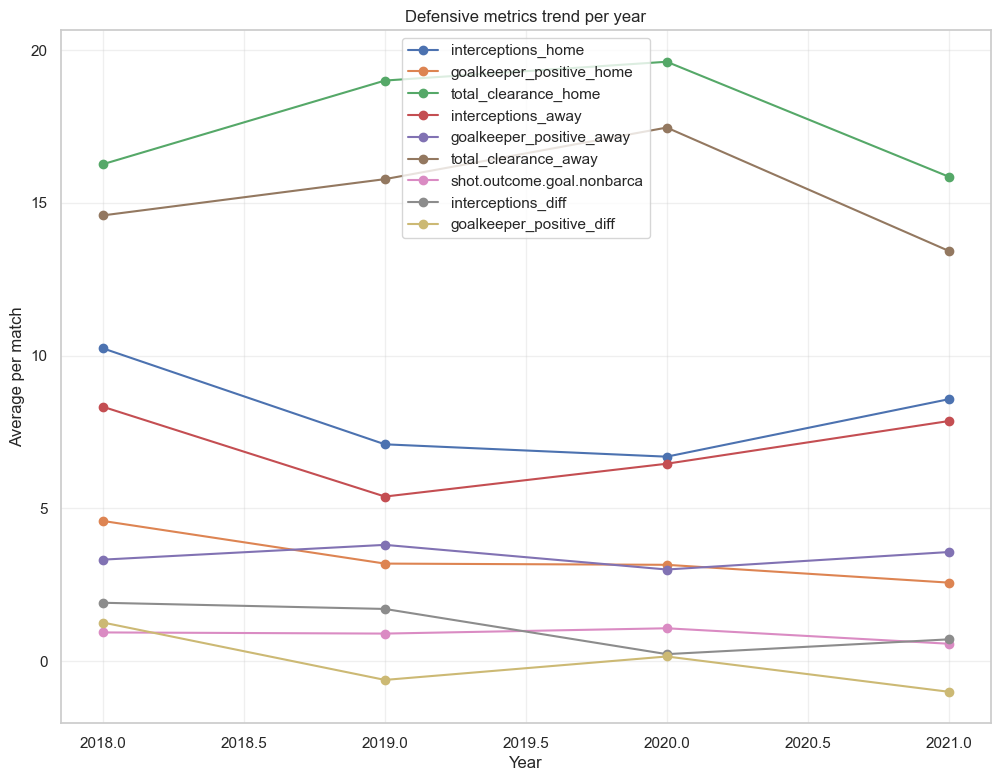

In [123]:
# Gunakan proxy defensive: duel counts, clearances, fouls
defensive_features = [c for c in df_merged.columns if any(k in c for k in ['duel','clearance','tackle','interception','conceded','nonbarca','goalkeeper'])]
print('Detected defensive-related columns:', defensive_features[:20])

if defensive_features:
    df_merged['match_date'] = pd.to_datetime(df_merged['match_date'])
    df_merged['year'] = df_merged['match_date'].dt.year
    def_summary = df_merged.groupby('year')[defensive_features].mean()
    print('\nAverage defensive metrics per year:')
    display(def_summary)

    # Plot trends for first few defensive metrics
    to_plot = defensive_features[:9]
    if to_plot:
        plt.figure(figsize=(12,9))
        for c in to_plot:
            if c in def_summary.columns:
                plt.plot(def_summary.index, def_summary[c], marker='o', label=c)
        plt.legend()
        plt.title('Defensive metrics trend per year')
        plt.xlabel('Year')
        plt.ylabel('Average per match')
        plt.grid(alpha=0.3)
        plt.show()
else:
    print('Tidak ditemukan kolom defensif yang jelas di df_merged. Pastikan aggregated defensive features dibuat saat agregasi events.')

Defensive columns detected: ['interceptions_home', 'goalkeeper_positive_home', 'total_clearance_home', 'interceptions_away', 'goalkeeper_positive_away', 'total_clearance_away', 'shot.outcome.goal.nonbarca', 'interceptions_diff', 'goalkeeper_positive_diff', 'total_clearance_diff']

Top opponents by matches (top 30):


opponent
Athletic Club             4
Granada                   4
Valencia                  4
Sevilla                   4
Real Valladolid           4
Real Sociedad             4
Real Madrid               4
Real Betis                4
Levante UD                4
Atlético Madrid           4
Leganés                   4
Getafe                    4
Espanyol                  4
Eibar                     4
Deportivo Alavés          4
Celta Vigo                4
Villarreal                4
Huesca                    3
Girona                    3
Osasuna                   3
Mallorca                  2
Cádiz                     2
Las Palmas                1
RC Deportivo La Coruña    1
Rayo Vallecano            1
Elche                     1
Name: (interceptions_home, count), dtype: int64


Defensive summary (mean) for top opponents:


,interceptions_home,goalkeeper_positive_home,total_clearance_home,interceptions_away,goalkeeper_positive_away,total_clearance_away,shot.outcome.goal.nonbarca,interceptions_diff,goalkeeper_positive_diff,total_clearance_diff
opponent,,,,,,,,,,
Getafe,14.750000,2.750000,16.25,5.500000,2.750000,15.25,0.500000,9.25,0.000000,1.000000
Elche,14.000000,1.000000,16.0,12.000000,4.000000,11.0,0.000000,2.00,-3.000000,5.000000
Athletic Club,12.750000,4.500000,23.0,7.500000,3.250000,19.5,0.250000,5.25,1.250000,3.500000
Deportivo Alavés,12.000000,3.500000,21.75,4.000000,4.250000,13.5,0.500000,8.00,-0.750000,8.250000
Girona,11.666667,4.333333,14.333333,6.666667,6.333333,11.0,0.666667,5.00,-2.000000,3.333333
RC Deportivo La Coruña,11.000000,4.000000,21.0,11.000000,5.000000,19.0,2.000000,0.00,-1.000000,2.000000
Cádiz,10.500000,6.000000,17.0,9.500000,3.500000,22.5,1.000000,1.00,2.500000,-5.500000
Eibar,10.000000,2.750000,30.0,8.750000,4.250000,14.0,0.500000,1.25,-1.500000,16.000000
Atlético Madrid,9.750000,4.250000,19.25,7.750000,2.250000,16.75,0.250000,2.00,2.000000,2.500000


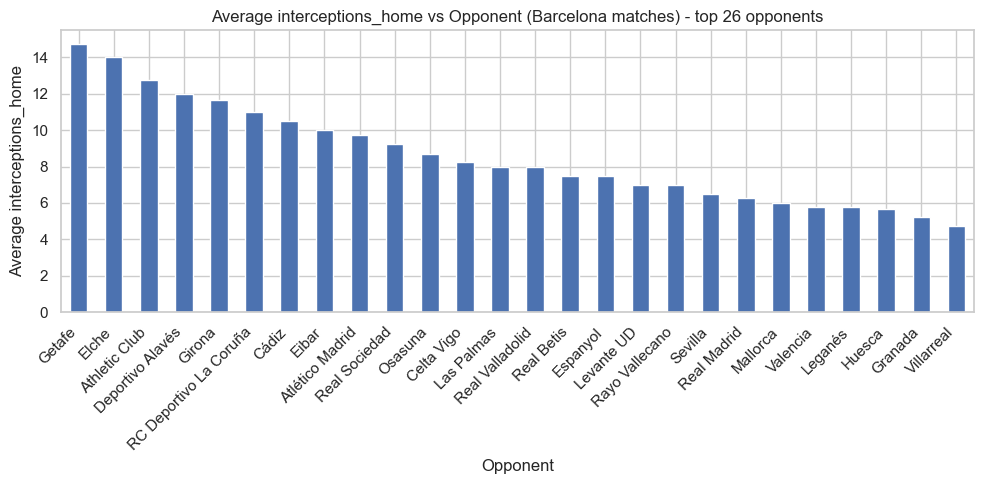

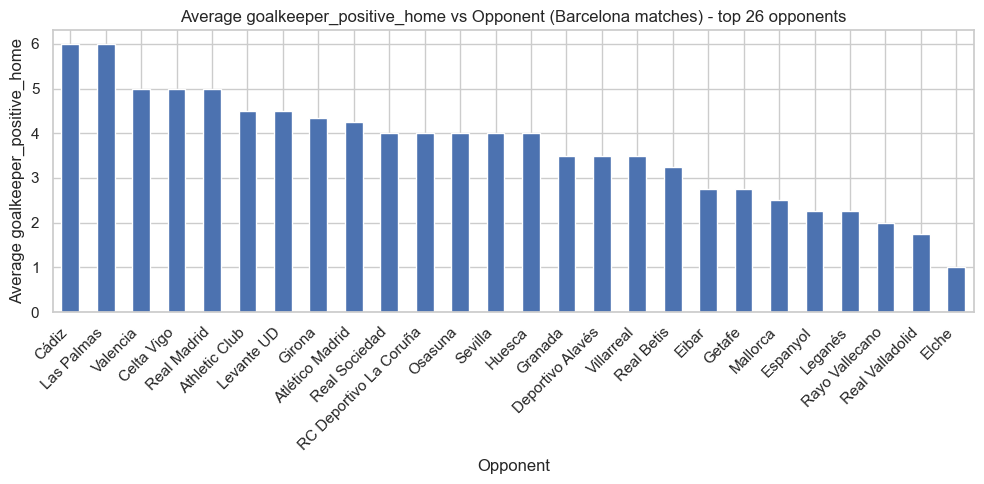

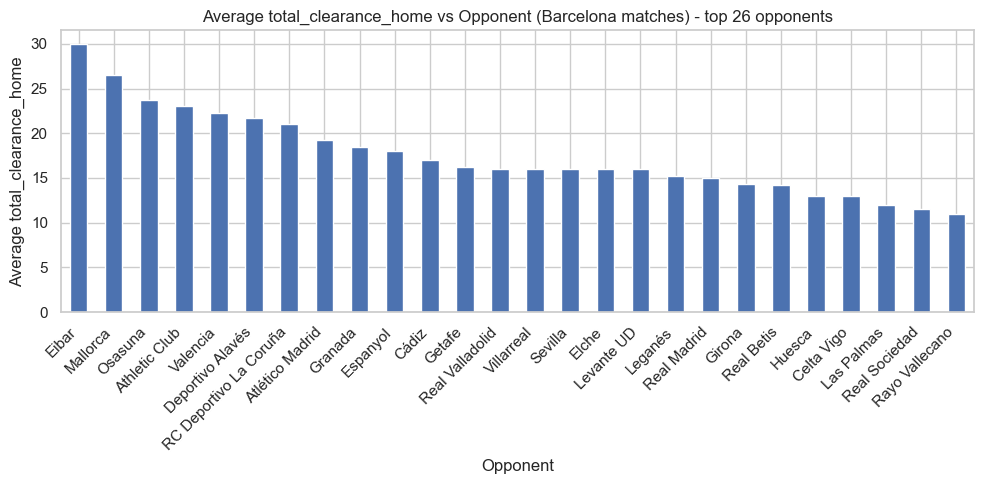

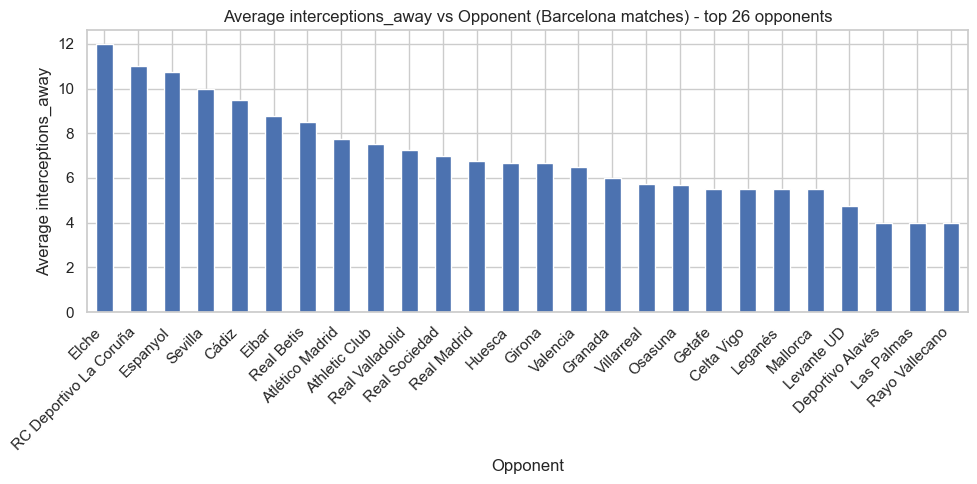

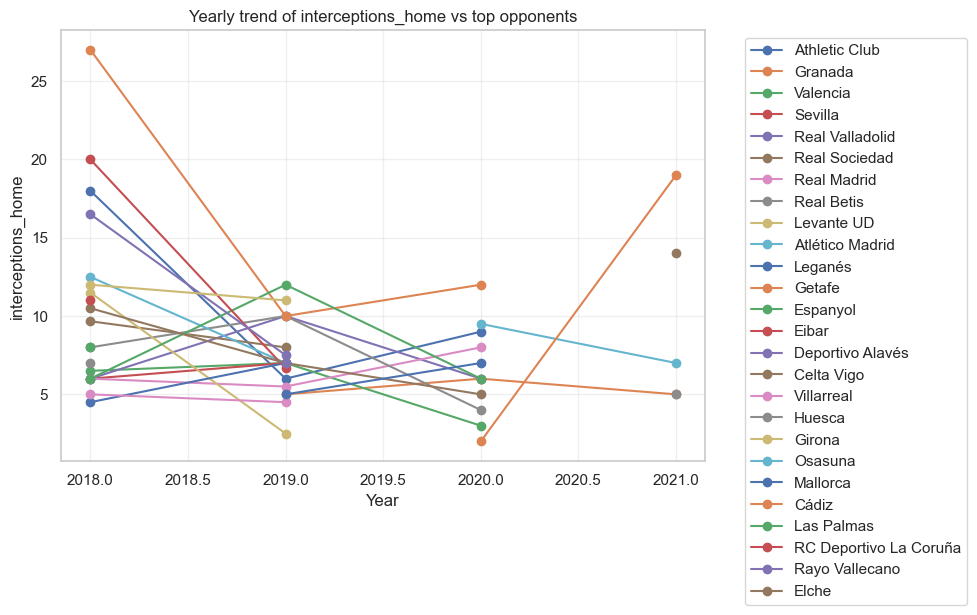

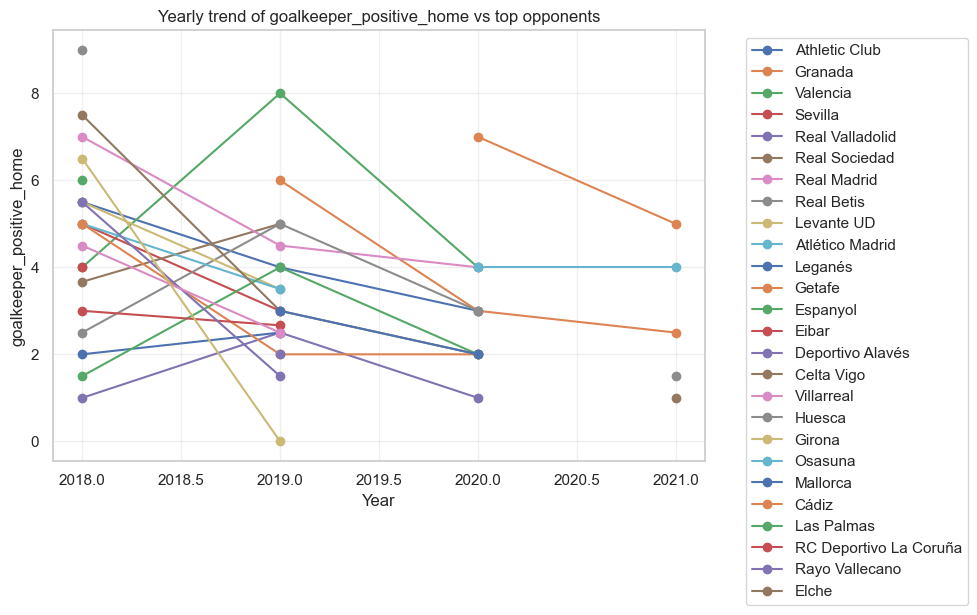

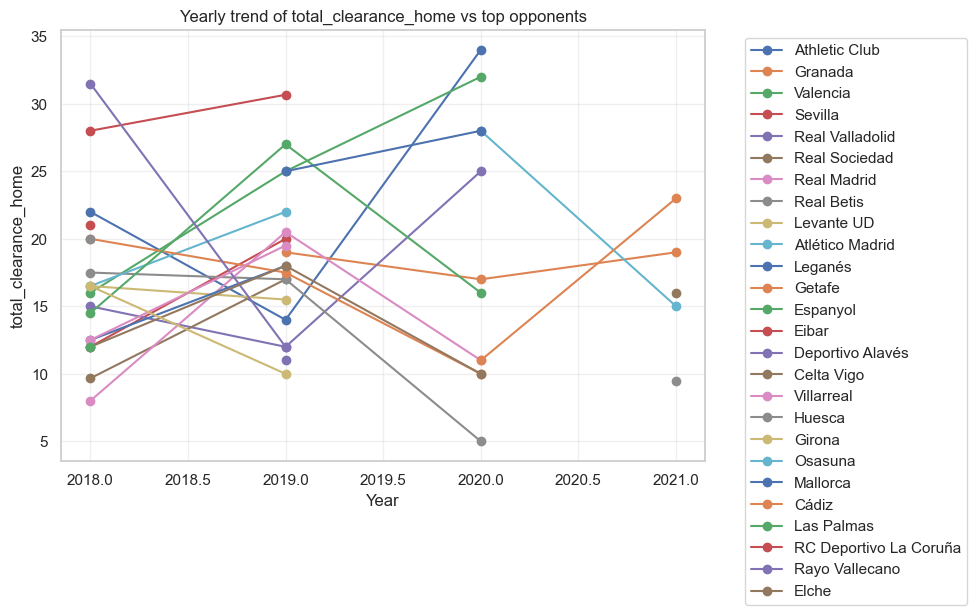

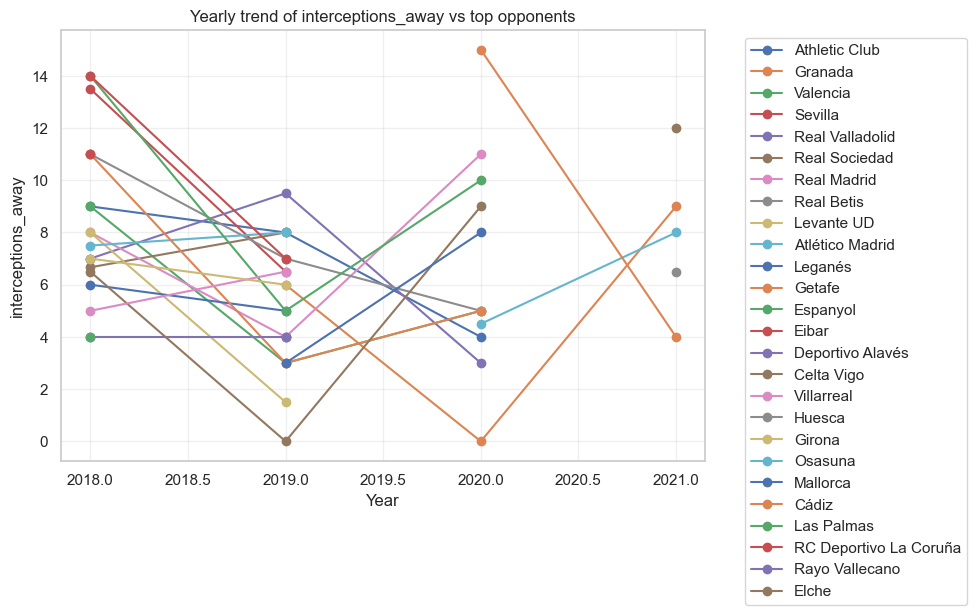

In [124]:
# 1) Fokus hanya pertandingan Barcelona
barca_mask = (
    df_merged['home_team.home_team_name'].astype(str).str.contains('barcelona', case=False, na=False) |
    df_merged['away_team.away_team_name'].astype(str).str.contains('barcelona', case=False, na=False)
)
df_barca = df_merged.loc[barca_mask].copy()
if df_barca.empty:
    print("Tidak ada match Barcelona ditemukan di df_merged.")
else:
    # 2) Tentukan lawan dan apakah Barca main kandang
    df_barca['barca_is_home'] = df_barca['home_team.home_team_name'].astype(str).str.contains('barcelona', case=False, na=False)
    df_barca['opponent'] = np.where(df_barca['barca_is_home'], df_barca['away_team.away_team_name'], df_barca['home_team.home_team_name'])
    df_barca['opponent'] = df_barca['opponent'].fillna('Unknown')

    # 3) Defensive columns (gunakan fitur agregat defensif yang sudah dibuat)
    defensive_cols = [c for c in df_barca.columns if any(k in c for k in ['duel','clearance','tackle','interception','conceded','nonbarca','goalkeeper'])]
    if not defensive_cols:
        print("Tidak ditemukan kolom defensif di df_merged. Pastikan agregasi defensif dibuat sebelumnya.")
    else:
        print("Defensive columns detected:", defensive_cols)

        # 4) Ringkasan per opponent
        opp_summary = df_barca.groupby('opponent')[defensive_cols].agg(['mean','std','count'])
        # tampilkan top opponent berdasarkan jumlah match
        opp_counts = opp_summary[ (defensive_cols[0],'count') ].sort_values(ascending=False)
        top_opponents = opp_counts.head(30).index.tolist()
        print("\nTop opponents by matches (top 30):")
        display(opp_counts.head(30))

        print("\nDefensive summary (mean) for top opponents:")
        display(opp_summary.loc[top_opponents].xs('mean', level=1, axis=1).sort_values(by=defensive_cols[0], ascending=False))

        # 5) Visualisasi: bar chart defensive metric per opponent (top N)
        import matplotlib.pyplot as plt
        import seaborn as sns
        sns.set(style="whitegrid")

        top_n = top_opponents[:30]
        metrics_to_plot = defensive_cols[:4]  # pilih beberapa metric defensif utama
        for metric in metrics_to_plot:
            plt.figure(figsize=(10,5))
            vals = df_barca.groupby('opponent')[metric].mean().loc[top_n].fillna(0)
            vals.sort_values(ascending=False).plot(kind='bar')
            plt.title(f"Average {metric} vs Opponent (Barcelona matches) - top {len(top_n)} opponents")
            plt.ylabel(f"Average {metric}")
            plt.xlabel("Opponent")
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()

        # 6) Trend per year untuk top opponents (lihat apakah ada adjustment)
        df_barca['match_date'] = pd.to_datetime(df_barca['match_date'], errors='coerce')
        df_barca['year'] = df_barca['match_date'].dt.year.fillna(0).astype(int)
        years = sorted(df_barca['year'].unique())

        for metric in metrics_to_plot:
            plt.figure(figsize=(10,6))
            for opp in top_n:
                series = df_barca[df_barca['opponent']==opp].groupby('year')[metric].mean().reindex(years)
                if series.notna().sum() > 0:
                    plt.plot(series.index, series.values, marker='o', label=opp)
            plt.title(f"Yearly trend of {metric} vs top opponents")
            plt.xlabel("Year")
            plt.ylabel(metric)
            plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

**2. Tentukan gaya permainan tim mayoritas yang digunakan oleh Barcelona dari tahun ke tahun dari data yang ada. (Beberapa playstyle yang terkenal seperti: Possession Game, Quick Counter, Long Ball Counter, Out Wide, Long Ball; di luar ini, juga banyak, bisa dieksplorasi lebih lanjut)**

In [281]:
def classify_playstyle_final(row):
    poss = row.get('possession', np.nan)
    
    if row['num_duel_z'] > 0.5:  
        return 'Gegenpressing'
    elif row['num_dribble_z'] > 0.5: 
        return 'Out Wide / Wing Play'
    elif row['num_shot_z'] > 0.3 and row['num_pass_z'] < 0 and (not pd.isna(poss) and poss < 45):
        return 'Defensive/Low Block'
    elif (not pd.isna(poss) and 50 <= poss <= 60) and abs(row['num_pass_z']) < 0.5:
        return 'Balanced'
    elif (row['num_pass_z'] > 0.3 and row['avg_pass_len_z'] < 0) or (not pd.isna(poss) and poss > 55):
        return 'Possession Game'
    else:
        return 'Adaptif'

# Klasifikasi playstyle
agg['playstyle'] = agg.apply(classify_playstyle_final, axis=1)
barca_agg_final = agg[agg['team_name'].str.contains('barcelona', case=False, na=False)]

print("Hasil klasifikasi Barcelona:")
display(barca_agg_final['playstyle'].value_counts())

# Merge data untuk analisis per pertandingan
matches = df_merged[['match_id', 'home_team.home_team_name', 'away_team.away_team_name', 'match_date']].copy()
matches.columns = ['match_id', 'home_team_name', 'away_team_name', 'match_date']
matches['year'] = pd.to_datetime(matches['match_date'], errors='coerce').dt.year

# Merge home & away teams dengan playstyle
home_agg = agg.add_prefix('home_').rename(columns={'home_match_id': 'match_id', 'home_team_name': 'team_name'})
away_agg = agg.add_prefix('away_').rename(columns={'away_match_id': 'match_id', 'away_team_name': 'team_name'})

merged = (matches
          .merge(home_agg, left_on=['match_id','home_team_name'], right_on=['match_id','team_name'], how='left')
          .merge(away_agg, left_on=['match_id','away_team_name'], right_on=['match_id','team_name'], how='left', suffixes=('_home','_away')))

# Filter Barcelona matches & extract metrics
barca_mask = (merged['home_team_name'].str.contains('barcelona', case=False, na=False) | 
              merged['away_team_name'].str.contains('barcelona', case=False, na=False))
barca = merged.loc[barca_mask].copy()

barca['barca_is_home'] = barca['home_team_name'].str.contains('barcelona', case=False, na=False)

# Extract Barcelona metrics per match
metrics_cols = ['playstyle', 'num_pass', 'avg_pass_len', 'num_dribble', 'num_duel']
for col in metrics_cols:
    barca[f'barca_{col}'] = np.where(barca['barca_is_home'], barca[f'home_{col}'], barca[f'away_{col}'])

# Merge possession data
if 'barca_possession' in df_merged.columns:
    barca = barca.merge(df_merged[['match_id', 'barca_possession']], on='match_id', how='left')

# Clean data & analyze
barca_clean = barca.dropna(subset=['year', 'barca_playstyle'])

Hasil klasifikasi Barcelona:


playstyle
Possession Game         40
Out Wide / Wing Play    21
Balanced                14
Gegenpressing            9
Defensive/Low Block      1
Name: count, dtype: int64


Metrics Barcelona per Tahun:


,barca_num_pass,barca_avg_pass_len,barca_num_dribble,barca_num_duel,barca_possession
year,,,,,
2018,678.21,18.93,29.88,23.62,63.00
2019,700.35,18.55,30.06,23.97,63.55
2020,803.54,18.03,28.62,23.92,71.08
2021,859.14,17.45,28.29,20.29,71.43



Karakteristik per Playstyle:


,barca_num_pass,barca_avg_pass_len,barca_num_dribble,barca_num_duel,barca_possession
barca_playstyle,,,,,
Balanced,575.57,19.46,26.86,20.50,53.64
Defensive/Low Block,487.00,18.71,24.00,15.00,44.00
Gegenpressing,669.22,19.04,31.22,34.00,64.89
Out Wide / Wing Play,733.00,18.23,40.29,23.67,66.10
Possession Game,781.72,18.25,24.78,22.35,69.22



Distribusi Playstyle per Tahun:


barca_playstyle,Balanced,Defensive/Low Block,Gegenpressing,Out Wide / Wing Play,Possession Game,dominant_style
year,,,,,,
2018,9,0,6,9,10,Possession Game
2019,5,1,3,7,15,Possession Game
2020,0,0,0,4,9,Possession Game
2021,0,0,0,1,6,Possession Game


<Figure size 1200x600 with 0 Axes>

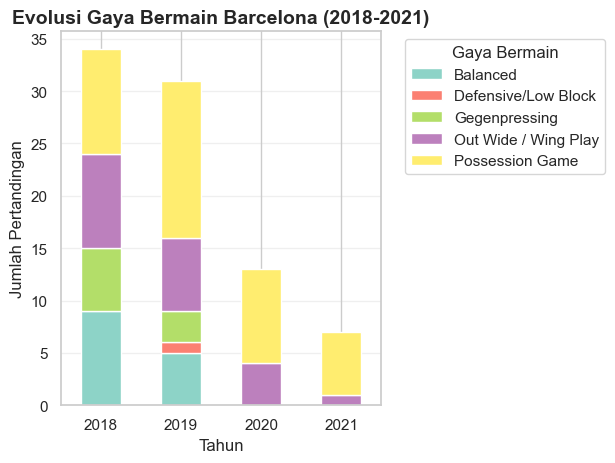

In [282]:
if len(barca_clean) > 0:
    # 1. Yearly metrics
    yearly_metrics = barca_clean.groupby('year').agg({
        'barca_num_pass': 'mean',
        'barca_avg_pass_len': 'mean', 
        'barca_num_dribble': 'mean',
        'barca_num_duel': 'mean',
        'barca_possession': 'mean'
    }).round(2)
    
    print("\nMetrics Barcelona per Tahun:")
    display(yearly_metrics)
    
    # 2. Playstyle characteristics
    playstyle_metrics = barca_clean.groupby('barca_playstyle').agg({
        'barca_num_pass': 'mean',
        'barca_avg_pass_len': 'mean',
        'barca_num_dribble': 'mean', 
        'barca_num_duel': 'mean',
        'barca_possession': 'mean'
    }).round(2)
    
    print("\nKarakteristik per Playstyle:")
    display(playstyle_metrics)
    
    # 3. Yearly playstyle distribution
    summary_final = barca_clean.groupby('year')['barca_playstyle'].value_counts().unstack(fill_value=0)
    summary_final['dominant_style'] = summary_final.idxmax(axis=1)
    
    print("\nDistribusi Playstyle per Tahun:")
    display(summary_final)
    
    # 4. Visualization
    plt.figure(figsize=(12, 6))
    summary_plot = summary_final.drop(columns='dominant_style')
    summary_plot.plot(kind='bar', stacked=True, colormap='Set3')
    plt.title('Evolusi Gaya Bermain Barcelona (2018-2021)', fontsize=14, fontweight='bold')
    plt.xlabel('Tahun')
    plt.ylabel('Jumlah Pertandingan')
    plt.legend(title='Gaya Bermain', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

**3. Apakah suatu formasi tertentu cenderung meng-counter formasi tim tertentu? Hubungkan dengan berbagai hal, misalnya pergerakan ofensif dan pengerakan defensif tim.**

Formation Analysis:


,Avg_Goals,Avg_Conceded,Win_Rate%,barca_passes,barca_dribbles,barca_interceptions,barca_clearances,barca_counterpress,barca_possession
formasi_barca,,,,,,,,,
4-2-4,4.50,1.00,100.00,65.0,14.5,9.5,7.5,59.5,51.0
4-5-1,2.00,0.00,100.00,58.0,8.0,8.0,17.0,54.0,62.0
5-4-1,4.50,0.50,100.00,63.5,14.0,6.5,10.5,64.5,63.0
4-4-2,2.06,0.75,68.75,80.5,13.6,11.4,16.3,55.3,63.6
4-3-3,2.37,1.00,66.67,78.8,13.4,8.6,18.3,54.9,65.5
5-3-2,1.00,1.00,50.00,75.2,9.8,6.8,19.2,50.5,74.5



Top Formation Matchups (min 2 games):


Avg_Goals  Win_Rate%  Games
formasi_barca formasi_lawan                             
5-4-1         5-3-2               4.50     100.00      2
4-3-3         4-3-3               2.08      76.92     13
4-4-2         4-5-1               2.25      75.00      4
4-3-3         5-2-3               2.57      71.43      7
4-4-2         4-4-2               1.29      71.43      7
4-3-3         4-5-1               2.00      66.67      6
              4-4-2               2.48      65.22     23
              5-3-2               2.55      54.55     11
5-3-2         4-4-2               1.00      50.00      2
4-4-2         4-3-3               1.67      33.33      3


Offensive:


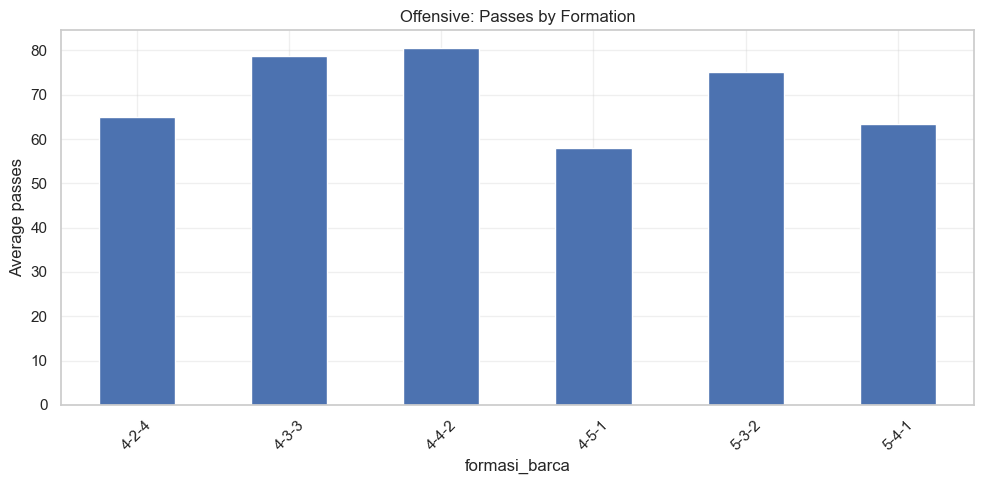

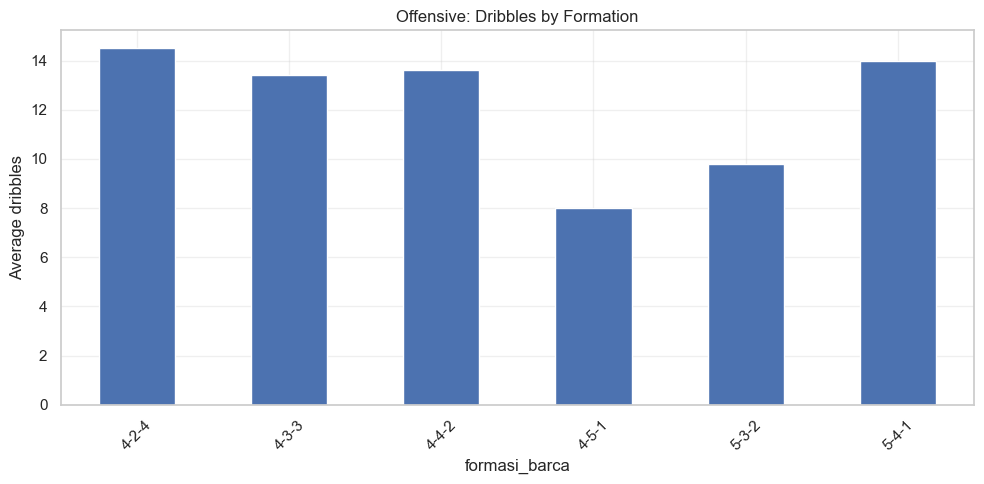

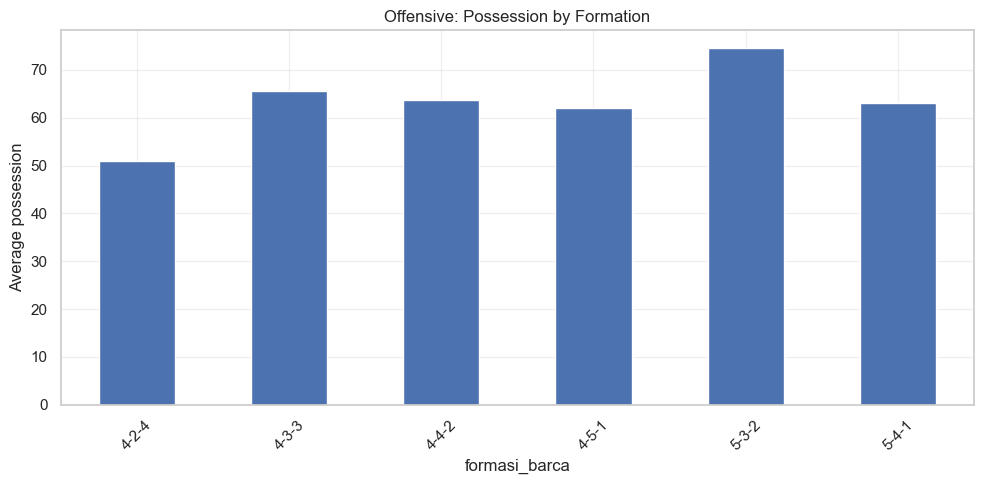


Defensive:


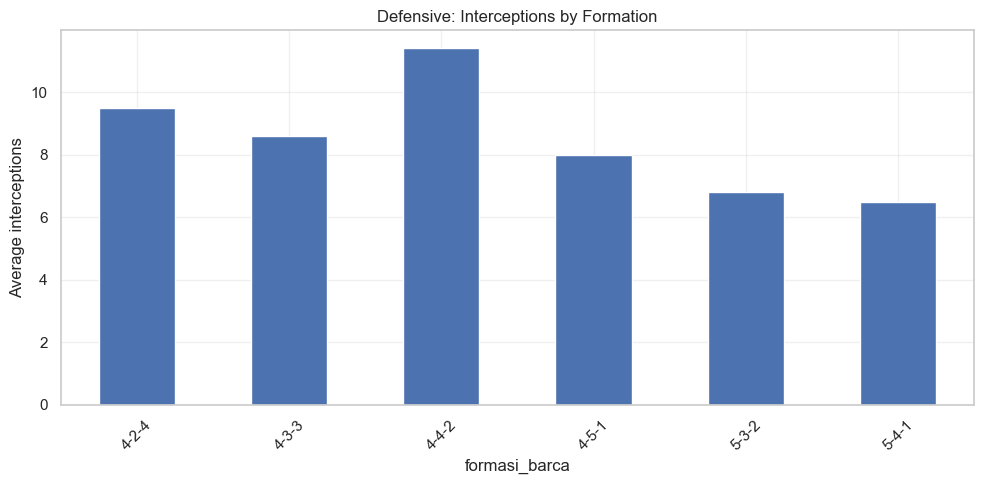

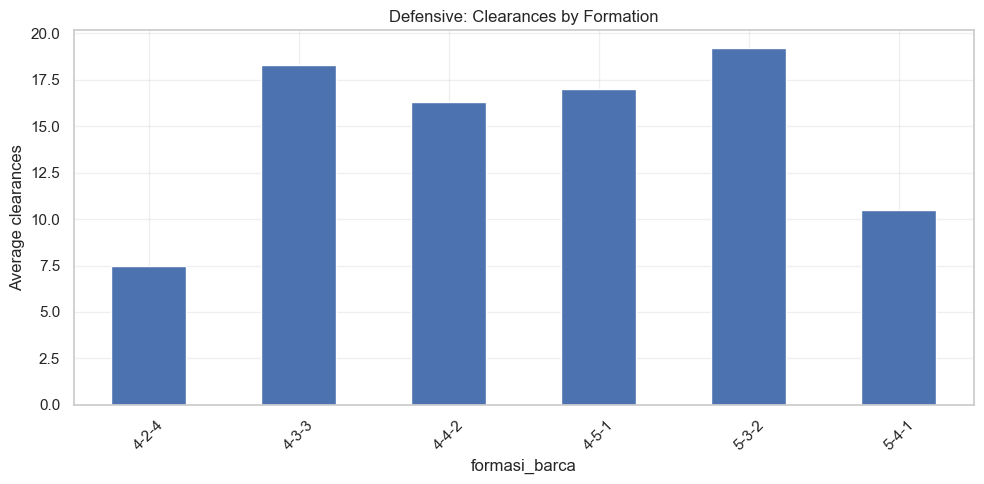

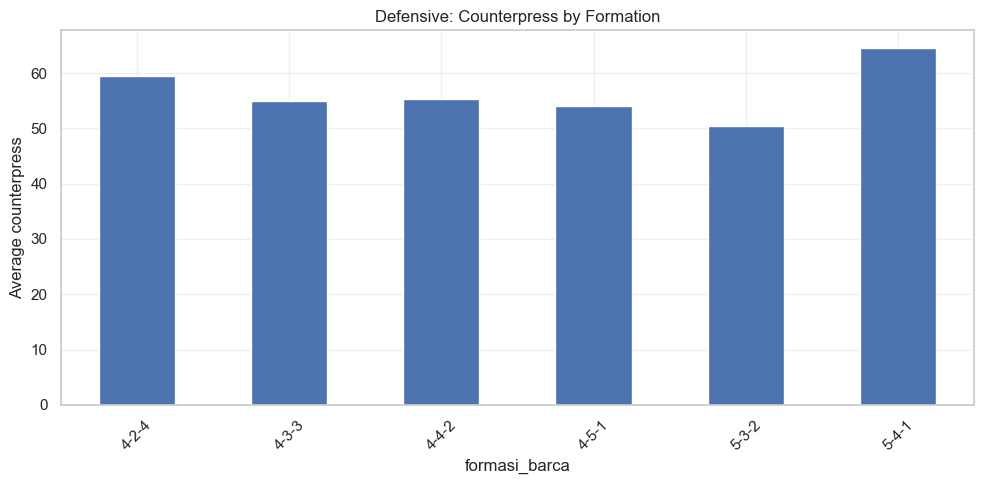

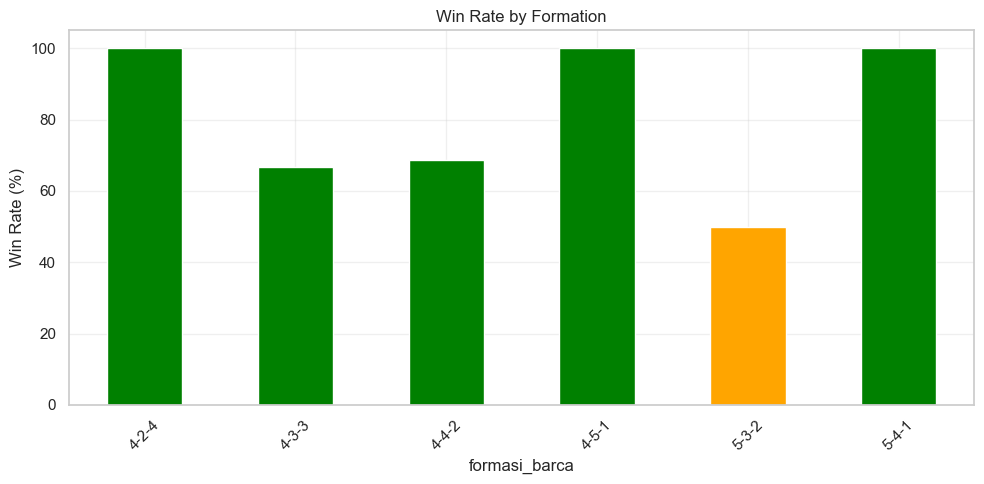

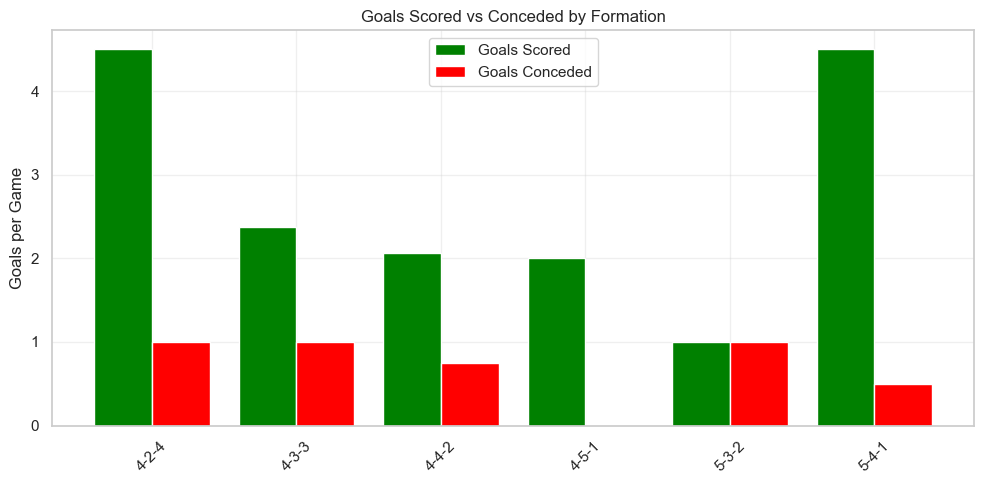

In [ ]:
if not barca_formation_df.empty:
    
    # ekstrak tactical metrics
    tactical_cols = ['successful_passes_home', 'successful_passes_away', 'successful_dribbles_home', 
                    'successful_dribbles_away', 'interceptions_home', 'interceptions_away',
                    'total_clearance_home', 'total_clearance_away', 'counterpress_sum_home', 
                    'counterpress_sum_away', 'barca_possession']
    
    existing_cols = [col for col in tactical_cols if col in df_merged.columns]
    barca_tactical = barca_formation_df.merge(df_merged[['match_id'] + existing_cols], on='match_id', how='left')
    
    # ekstrak Barcelona metrics
    metric_mapping = {
        'barca_passes': ('successful_passes_home', 'successful_passes_away'),
        'barca_dribbles': ('successful_dribbles_home', 'successful_dribbles_away'),
        'barca_interceptions': ('interceptions_home', 'interceptions_away'),
        'barca_clearances': ('total_clearance_home', 'total_clearance_away'),
        'barca_counterpress': ('counterpress_sum_home', 'counterpress_sum_away')
    }
    
    for metric, (home_col, away_col) in metric_mapping.items():
        if home_col in barca_tactical.columns and away_col in barca_tactical.columns:
            barca_tactical[metric] = np.where(barca_tactical['is_home'], 
                                            barca_tactical[home_col], barca_tactical[away_col])
    
    available_metrics = [m for m in metric_mapping.keys() if m in barca_tactical.columns]
    if 'barca_possession' in barca_tactical.columns:
        available_metrics.append('barca_possession')
    
    # analisis formasi
    formation_stats = barca_formation_df.groupby('formasi_barca').agg({
        'gol_barca': 'mean', 'gol_lawan': 'mean', 'hasil': lambda x: (x == 'Win').sum() / len(x) * 100
    }).round(2)
    formation_stats.columns = ['Avg_Goals', 'Avg_Conceded', 'Win_Rate%']
    
    if available_metrics:
        tactical_stats = barca_tactical.groupby('formasi_barca')[available_metrics].mean().round(1)
        formation_stats = formation_stats.join(tactical_stats)
    
    print("Analisis Formasi:")
    display(formation_stats.sort_values('Win_Rate%', ascending=False))
    
    # analisis counter formasi
    counter_stats = barca_formation_df.groupby(['formasi_barca', 'formasi_lawan']).agg({
        'gol_barca': 'mean', 'hasil': lambda x: (x == 'Win').sum() / len(x) * 100, 'formasi_barca': 'count'
    }).round(2)
    counter_stats.columns = ['Avg_Goals', 'Win_Rate%', 'Games']
    counter_stats = counter_stats[counter_stats['Games'] >= 2].sort_values('Win_Rate%', ascending=False)
    
    print("\nTop Counter Formasi (min 2 games):")
    display(counter_stats)
    
    # kategorisasi metrics
    offensive_metrics = [m for m in ['barca_passes', 'barca_dribbles', 'barca_possession'] if m in available_metrics]
    defensive_metrics = [m for m in ['barca_interceptions', 'barca_clearances', 'barca_counterpress'] if m in available_metrics]
    
    # visualisasi
    if offensive_metrics:
        print("\nOffensive:")
        for metric in offensive_metrics:
            plt.figure(figsize=(10,5))
            formation_stats[metric].plot(kind='bar')
            plt.title(f"Offensive: {metric.replace('barca_', '').title()} by Formation")
            plt.ylabel(f"Average {metric.replace('barca_', '')}")
            plt.xticks(rotation=45)
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()
    
    if defensive_metrics:
        print("\nDefensive:")
        for metric in defensive_metrics:
            plt.figure(figsize=(10,5))
            formation_stats[metric].plot(kind='bar')
            plt.title(f"Defensive: {metric.replace('barca_', '').title()} by Formation")
            plt.ylabel(f"Average {metric.replace('barca_', '')}")
            plt.xticks(rotation=45)
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()
    
    # visualisasi win rate
    plt.figure(figsize=(10,5))
    formation_stats['Win_Rate%'].plot(kind='bar', color=['green' if x >= 60 else 'orange' if x >= 40 else 'red' for x in formation_stats['Win_Rate%']])
    plt.title("Win Rate by Formation")
    plt.ylabel("Win Rate (%)")
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # komparasi gol
    plt.figure(figsize=(10,5))
    x = range(len(formation_stats))
    plt.bar([i-0.2 for i in x], formation_stats['Avg_Goals'], 0.4, label='Goals Scored', color='green')
    plt.bar([i+0.2 for i in x], formation_stats['Avg_Conceded'], 0.4, label='Goals Conceded', color='red')
    plt.xticks(x, formation_stats.index, rotation=45)
    plt.ylabel("Goals per Game")
    plt.title("Goals Scored vs Conceded by Formation")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

**Kesimpulan:** Terlihat bahwa Barcelona memiliki 6 variasi formasi dan menyesuaikan/meng-counter formasi lawan. Secara defensive Barcelona paling bagus saat memainkan formasi 4-4-2 (interception), 5-4-1 (counterpress), dan 5-3-2 (clearence). Namun, bisa dikatakan 5-4-1 dan 4-2-4 lebih efektif karena memiliki persentase kemenangan 100%. Sedangkan, secara offensive Barcelona lebih baik bermain dengan formasi 4-2-4 (dribble), 4-4-2 (passing), dan 5-3-2 (possession). Namun, 4-2-4 paling efektif untuk digunakan apabila menyerang karena memiliki persentase kemenangan 100% dan rata-rata gol tertinggi yaitu 4.5. Sehingga, dapat disimpulkan bahwa 4-2-4 adalah formasi terbaik untuk digunakan oleh Barcelona.

**4. Siapakah pemain Barcelona yang kerap menjadi pemecah kebuntuan tim (ketika hasil masih defisit atau seri bagi tim yang bersangkutan) dalam dataset ini?**

Terdapat 274 goal-event yang terdeteksi (berdasarkan kolom shot.outcome.name).


,player.name,shot.outcome.name,possession_team.name,match_id
775,Arturo Erasmo Vidal Pardo,Goal,Barcelona,303680
5438,Luis Alberto Suárez Díaz,Goal,Barcelona,16095
5660,Lionel Andrés Messi Cuccittini,Goal,Barcelona,16095
5803,Lionel Andrés Messi Cuccittini,Goal,Barcelona,16095
6271,Lionel Andrés Messi Cuccittini,Goal,Barcelona,16095
7273,Gerard Piqué Bernabéu,Goal,Barcelona,16095
9475,Ousmane Dembélé,Goal,Barcelona,15956
10788,Ezequiel Marcelo Garay,Goal,Valencia,16023
11740,Lionel Andrés Messi Cuccittini,Goal,Barcelona,16023
15769,Youssef En-Nesyri,Goal,Leganés,303715



Top pemain yang menjadi pemecah kebuntuan (hanya Barcelona):


Lionel Andrés Messi Cuccittini      39
Luis Alberto Suárez Díaz            19
Ousmane Dembélé                      7
Arturo Erasmo Vidal Pardo            7
Philippe Coutinho Correia            6
Antoine Griezmann                    6
Gerard Piqué Bernabéu                4
Ivan Rakitić                         3
Clément Lenglet                      3
Francisco Alcácer García             2
Jordi Alba Ramos                     2
Frenkie de Jong                      2
Cristian Portugués Manzanera         1
Munir El Haddadi Mohamed             1
José Paulo Bezzera Maciel Júnior     1
Nélson Cabral Semedo                 1
Carles Aleña Castillo                1
Sergio Busquets i Burgos             1
Álvaro Negredo Sánchez               1
Martin Braithwaite Christensen       1
dtype: int64

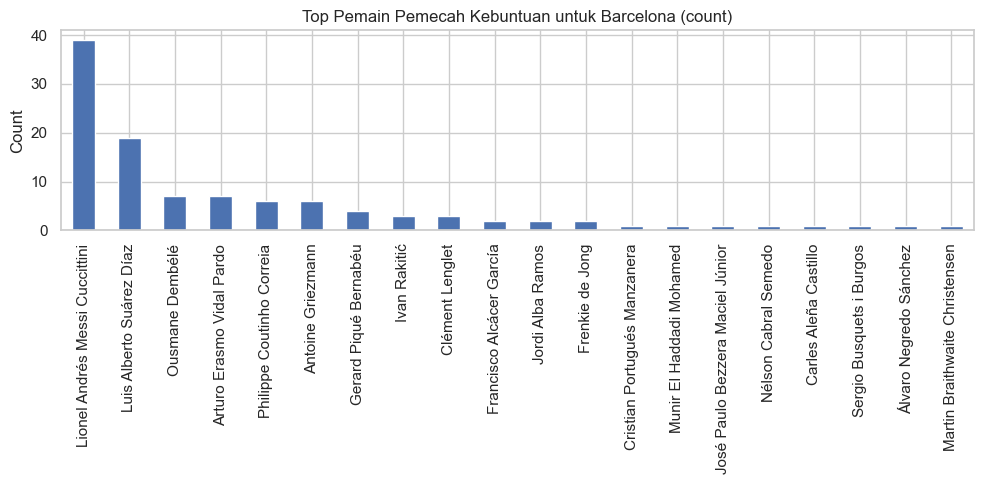

In [125]:
# Flexible detection of goal events & team column
team_col = None
for candidate in ['possession_team.name', 'team.name', 'team', 'possession_team']:
    if candidate in events_data.columns:
        team_col = candidate
        break

goal_col = None
if 'shot.outcome.name' in events_data.columns:
    goal_col = 'shot.outcome.name'
elif 'type.name' in events_data.columns:
    goal_col = 'type.name'

if team_col is None or goal_col is None or 'player.name' not in events_data.columns:
    print('Kolom yang dibutuhkan tidak lengkap di events_data. Diperlukan kolom: player.name, team identifier (possession_team.name atau team.name), dan kolom yang menandai goal (shot.outcome.name atau type.name).')
else:
    ev = events_data.copy().reset_index()
    ev['is_goal'] = ev[goal_col].astype(str).str.contains('goal', case=False, na=False)
    goals = ev[ev['is_goal']].copy()
    print(f'Terdapat {len(goals)} goal-event yang terdeteksi (berdasarkan kolom {goal_col}).')

    #display player.name,shot.outcome.name,team_col,match_id
    display(goals[['player.name', goal_col, team_col, 'match_id']].head(100))
    
    # Build timeline per match
    from collections import defaultdict
    scorer_counts = defaultdict(int)
    match_summaries = []

    for mid, gdf in goals.groupby('match_id'):
        gdf = gdf.sort_values('index')  # asumsi urutan kronologis sesuai index
        # Determine home/away team names from match_data
        row = match_data[match_data['match_id'] == mid]
        if row.empty:
            continue
        home = row.iloc[0].get('home_team.home_team_name', None)
        away = row.iloc[0].get('away_team.away_team_name', None)

        # track scores
        score = {home:0, away:0}
        # iterate goal events
        for _, evrow in gdf.iterrows():
            team = evrow[team_col]
            player = evrow.get('player.name', None)
            if pd.isna(team) or pd.isna(player):
                continue
            # before the goal
            opp = home if team == away else away
            team_before = score.get(team, 0)
            opp_before = score.get(opp, 0)
            # condition: previously trailing or tied
            if team_before <= opp_before:
                # count if this team is Barcelona (either home or away)
                if (str(team).lower() == 'barcelona') or (home == 'Barcelona' and team==home) or (away == 'Barcelona' and team==away):
                    scorer_counts[player] += 1
            # update score (assume goal increments by 1)
            score[team] = team_before + 1

    # Show top players
    scorer_series = pd.Series(scorer_counts).sort_values(ascending=False)
    print('\nTop pemain yang menjadi pemecah kebuntuan (hanya Barcelona):')
    if scorer_series.empty:
        print('Tidak ditemukan goal-event yang memenuhi kondisi atau kolom team names tidak konsisten.')
    else:
        display(scorer_series.head(20))
        scorer_series.head(20).plot(kind='bar', figsize=(10,5))
        plt.title('Top Pemain Pemecah Kebuntuan untuk Barcelona (count)')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

**5. Apakah possession yang lebih tinggi berkorelasi dengan xG / shots on target / peluang bersih?**

**6. Siapa pemain yang paling sering menjadi "creator" sebelum shot (pass langsung sebelum shot)?**

,passer,creations,creations_goal,teams,goal_rate
145,Lionel Andrés Messi Cuccittini,180,31,Barcelona,0.172222
189,Ousmane Dembélé,75,9,Barcelona,0.120000
150,Luis Alberto Suárez Díaz,74,12,Barcelona,0.162162
123,Jordi Alba Ramos,68,10,Barcelona,0.147059
201,Philippe Coutinho Correia,49,6,Barcelona,0.122449
236,Sergio Busquets i Burgos,31,1,Barcelona,0.032258
25,Arturo Erasmo Vidal Pardo,25,6,Barcelona,0.240000
104,Ivan Rakitić,25,5,Barcelona,0.200000
234,Sergi Roberto Carnicer,25,3,Barcelona,0.120000
22,Antoine Griezmann,24,5,Barcelona,0.208333


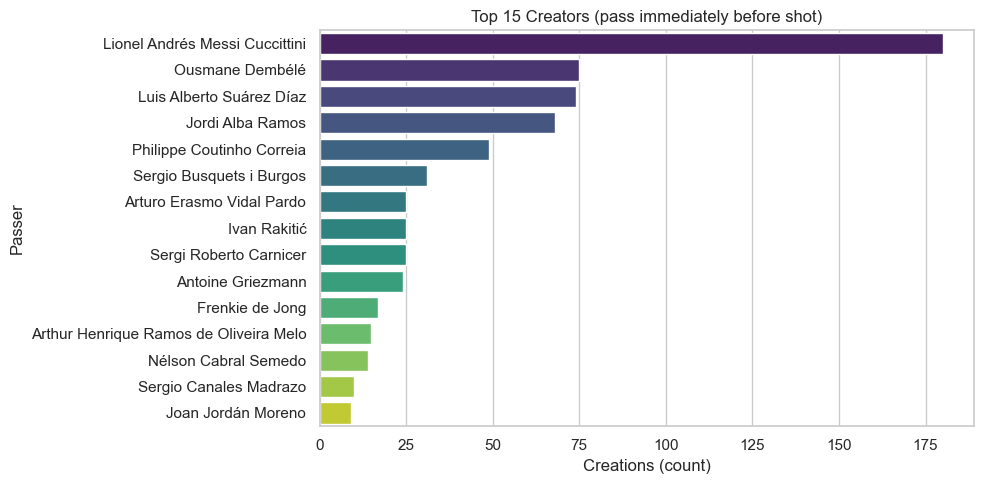

,passer,creations,goals,goal_rate
20,Lionel Andrés Messi Cuccittini,180,31,0.172222
29,Ousmane Dembélé,75,9,0.120000
22,Luis Alberto Suárez Díaz,74,12,0.162162
18,Jordi Alba Ramos,68,10,0.147059
31,Philippe Coutinho Correia,49,6,0.122449
36,Sergio Busquets i Burgos,31,1,0.032258
17,Ivan Rakitić,25,5,0.200000
7,Arturo Erasmo Vidal Pardo,25,6,0.240000
34,Sergi Roberto Carnicer,25,3,0.120000
5,Antoine Griezmann,22,4,0.181818


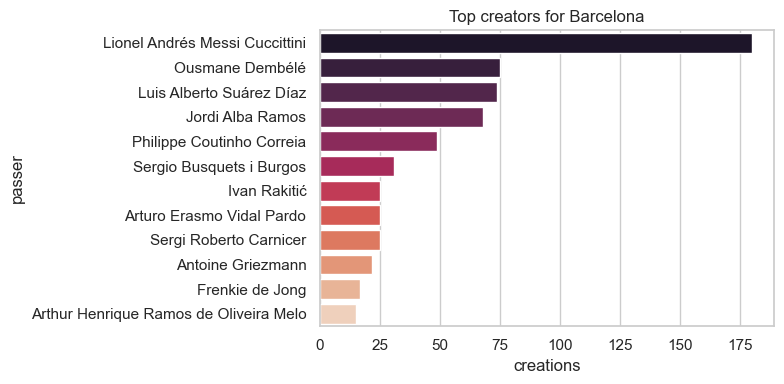

,season,passer,ct
86,2018,Lionel Andrés Messi Cuccittini,80
113,2018,Ousmane Dembélé,47
90,2018,Luis Alberto Suárez Díaz,40
71,2018,Jordi Alba Ramos,36
118,2018,Philippe Coutinho Correia,36
223,2019,Lionel Andrés Messi Cuccittini,59
226,2019,Luis Alberto Suárez Díaz,32
240,2019,Ousmane Dembélé,18
168,2019,Arturo Erasmo Vidal Pardo,14
213,2019,Jordi Alba Ramos,14


In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# safe copies
ev = events_data.copy() if 'events_data' in globals() else None
md = match_data.copy() if 'match_data' in globals() else None

if ev is None or md is None:
    print("events_data atau match_data tidak tersedia — jalankan sel load dataset terlebih dahulu.")
else:
    # Normalize index / ordering (assume dataframe order is chronological if no timestamp)
    ev = ev.reset_index(drop=False).rename(columns={'index': 'orig_index'})
    ev = ev.sort_values(['match_id','orig_index']).reset_index(drop=True)

    # Detect columns
    team_col = next((c for c in ['team.name','possession_team.name','team'] if c in ev.columns), None)
    player_col = next((c for c in ['player.name','player'] if c in ev.columns), None)
    type_col = next((c for c in ['type.name','event.type','type'] if c in ev.columns), None)
    shot_outcome_col = next((c for c in ['shot.outcome.name','shot.outcome','type.name'] if c in ev.columns), None)
    pass_shot_assist_col = next((c for c in ['pass.shot_assist','pass.shot_assist.name','pass.shot_assist_flag'] if c in ev.columns), None)

    def is_shot_row(r):
        # robust shot detection
        if type_col and isinstance(r.get(type_col), str) and 'shot' in r.get(type_col).lower():
            return True
        if shot_outcome_col and isinstance(r.get(shot_outcome_col), str) and any(k in r.get(shot_outcome_col).lower() for k in ('goal','on target','saved','shot')):
            return True
        return False

    def is_pass_row(r):
        if type_col and isinstance(r.get(type_col), str) and 'pass' in r.get(type_col).lower():
            return True
        # fallback: presence of pass.recipient.name or pass.outcome.name
        if 'pass.recipient.name' in ev.columns and pd.notna(r.get('pass.recipient.name')):
            return True
        if 'pass.outcome.name' in ev.columns and pd.notna(r.get('pass.outcome.name')):
            return True
        return False

    ev['_is_shot'] = ev.apply(is_shot_row, axis=1)
    ev['_is_pass'] = ev.apply(is_pass_row, axis=1)

    # Look-back N events to find passer before each shot (same match, prefer same team)
    N_LOOKBACK = 3
    creators_rows = []
    for match_id, g in ev.groupby('match_id', sort=False):
        g = g.reset_index(drop=True)
        for i, row in g[g['_is_shot']].iterrows():
            shooter = row.get(player_col, None)
            shooter_team = row.get(team_col, None)
            shot_idx = row.name
            shot_goal = 0
            if shot_outcome_col and pd.notna(row.get(shot_outcome_col)):
                try:
                    shot_goal = int(str(row.get(shot_outcome_col)).lower().count('goal')>0)
                except:
                    shot_goal = 0
            # search back up to N_LOOKBACK (only within same match order)
            passer = None
            passer_team = None
            pass_type = None
            pass_shot_assist = 0
            for j in range(max(0, i - N_LOOKBACK), i)[::-1]:
                prev = g.iloc[j]
                if prev['_is_pass']:
                    # require same team for creator
                    if pd.notna(prev.get(team_col)) and pd.notna(shooter_team) and str(prev.get(team_col)).strip().lower() == str(shooter_team).strip().lower():
                        passer = prev.get(player_col, None)
                        passer_team = prev.get(team_col, None)
                        # pass type fields if available
                        for c in ['pass.type.name','pass.height.name','pass.body_part.name','pass.recipient.name']:
                            if c in prev.index and pd.notna(prev.get(c)):
                                pass_type = prev.get(c)
                                break
                        if pass_shot_assist_col and pass_shot_assist_col in prev.index:
                            try:
                                pass_shot_assist = int(bool(prev.get(pass_shot_assist_col)))
                            except:
                                pass_shot_assist = 0
                        break
            creators_rows.append({
                'match_id': match_id,
                'shot_index': row['orig_index'],
                'shooter': shooter,
                'shooter_team': shooter_team,
                'passer': passer,
                'passer_team': passer_team,
                'pass_type': pass_type,
                'pass_shot_assist': pass_shot_assist,
                'is_goal': shot_goal
            })

    creators_df = pd.DataFrame(creators_rows)
    # drop shots without identified passer
    creators_with_pass = creators_df[creators_df['passer'].notna()].copy()

    if creators_with_pass.empty:
        print("Tidak ditemukan pass langsung sebelum shot (per konfigurasi). Cek nama kolom atau naikkan N_LOOKBACK.")
    else:
        # Aggregate overall creators
        agg = creators_with_pass.groupby('passer').agg(
            creations=('passer', 'count'),
            creations_goal=('is_goal', 'sum'),
            teams=('passer_team', lambda x: x.mode().iloc[0] if len(x.mode())>0 else np.nan)
        ).reset_index().sort_values('creations', ascending=False)

        # Add conversion and xG per creation
        agg['goal_rate'] = agg['creations_goal'] / agg['creations']

        display(agg.head(30))

        # Top creators plot
        topn = 15
        plt.figure(figsize=(10,5))
        sns.barplot(data=agg.head(topn), x='creations', y='passer', palette='viridis')
        plt.title(f'Top {topn} Creators (pass immediately before shot)')
        plt.xlabel('Creations (count)')
        plt.ylabel('Passer')
        plt.tight_layout()
        plt.show()

        # Barcelona-specific creators (if team names present)
        if creators_with_pass['passer_team'].notna().any():
            is_barca = creators_with_pass['passer_team'].astype(str).str.contains('barcelona', case=False, na=False)
            barca_creators = creators_with_pass[is_barca].copy()
            if not barca_creators.empty:
                agg_barca = barca_creators.groupby('passer').agg(
                    creations=('passer','count'),
                    goals=('is_goal','sum'),
                ).reset_index().sort_values('creations', ascending=False)
                agg_barca['goal_rate'] = agg_barca['goals'] / agg_barca['creations']
                display(agg_barca.head(20))
                plt.figure(figsize=(8,4))
                sns.barplot(data=agg_barca.head(12), x='creations', y='passer', palette='rocket')
                plt.title('Top creators for Barcelona')
                plt.tight_layout()
                plt.show()
            else:
                print("Tidak ada creators dengan passer_team mengandung 'barcelona'.")

        # Per-season (optional) — merge match -> season if match_date/season exists
        if 'match_date' in md.columns or 'season' in md.columns:
            md2 = md[['match_id'] + (['season'] if 'season' in md.columns else []) + (['match_date'] if 'match_date' in md.columns else [])].copy()
            if 'match_date' in md2.columns and 'season' not in md2.columns:
                md2['match_date'] = pd.to_datetime(md2['match_date'], errors='coerce')
                md2['season'] = md2['match_date'].dt.year
            creators_season = creators_with_pass.merge(md2[['match_id','season']], on='match_id', how='left')
            season_table = creators_season.groupby(['season','passer']).agg(ct=('passer','count')).reset_index()
            # show top passer per season
            top_per_season = season_table.sort_values(['season','ct'], ascending=[True,False]).groupby('season').head(5)
            display(top_per_season)